# 01. EDA (DAY 1)
각 문항은 `그래프 -> 발견 -> 시사점` 3단으로 정리한다. 그래프 나열 금지.
대상: Batch 1 + 2 + 3, 배치 간 비교 포함.

In [1]:
import sys; sys.path.append("..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.config import *
from src.load_data import load_all
from src.preprocess import select_valid, cell_table, parse_policy

plt.rcParams.update({"font.family": "AppleGothic", "axes.unicode_minus": False, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
BATCH_COLOR = {"batch1": "#1f77b4", "batch2": "#e07b00", "batch3": "#2a9d8f"}
BATCH_NAME = {"batch1": "Batch 1", "batch2": "Batch 2", "batch3": "Batch 3"}
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 3개 배치 로딩 -> 유효 셀 선별 (제외 셀은 사유 표로 보관)
all_cells = load_all()
valid, excluded = {}, []
for b, cells in all_cells.items():
    v, e = select_valid(cells)
    valid[b] = v
    excluded.append(e)
excluded = pd.concat(excluded, ignore_index=True)

# 유효 셀 요약표 + 초기 사이클(2~100) 평균 피처 (원인 탐색용)
ct = pd.concat([cell_table(v) for v in valid.values()])
early = {cid: c["summary"].loc[2:100, ["chargetime", "Tavg", "IR"]].mean() for v in valid.values() for cid, c in v.items()}
ct = ct.join(pd.DataFrame(early).T.add_prefix("early_"))
print({b: len(v) for b, v in valid.items()}, "| 제외:", len(excluded))

{'batch1': 46, 'batch2': 39, 'batch3': 44} | 제외: 10


## Q1. Cycle Life 분포

- [ ] 150~2,300 히스토그램
- [ ] 장수명(>1,000)/단수명(<500) 비율
- [ ] 이상치 셀 식별과 원인

In [2]:
# Q1-a. 배치별 수명 요약 통계와 장/단수명 비율
def life_summary(s):
    return pd.Series({"n_cells": len(s), "min": s.min(), "p25": s.quantile(.25), "median": s.median(),
                      "p75": s.quantile(.75), "max": s.max(), "mean": s.mean(), "std": s.std(),
                      "<500 (n)": int((s < 500).sum()), "500~1000 (n)": int(((s >= 500) & (s <= 1000)).sum()),
                      ">1000 (n)": int((s > 1000).sum()), "<550 (n)": int((s < 550).sum())})
tbl = ct.groupby("batch")["cycle_life"].apply(life_summary).unstack()
tbl.loc["all"] = life_summary(ct["cycle_life"])
tbl["<500 비율(%)"] = (tbl["<500 (n)"] / tbl["n_cells"] * 100).round(1)
tbl[">1000 비율(%)"] = (tbl[">1000 (n)"] / tbl["n_cells"] * 100).round(1)
tbl["<550 비율(%)"] = (tbl["<550 (n)"] / tbl["n_cells"] * 100).round(1)
display(tbl.round(1))

,n_cells,min,p25,median,p75,max,mean,std,<500 (n),500~1000 (n),>1000 (n),<550 (n),<500 비율(%),>1000 비율(%),<550 비율(%)
batch,,,,,,,,,,,,,,,
batch1,46.0,534.0,703.2,858.5,914.2,1227.0,844.7,184.6,0.0,36.0,10.0,1.0,0.0,21.7,2.2
batch2,39.0,392.0,439.5,472.0,508.5,1186.0,565.7,222.2,28.0,8.0,3.0,30.0,71.8,7.7,76.9
batch3,44.0,541.0,828.0,1005.5,1155.2,1935.0,1059.7,313.9,0.0,21.0,23.0,1.0,0.0,52.3,2.3
all,129.0,392.0,559.0,828.0,1017.0,1935.0,833.7,315.0,28.0,65.0,36.0,32.0,21.7,27.9,24.8


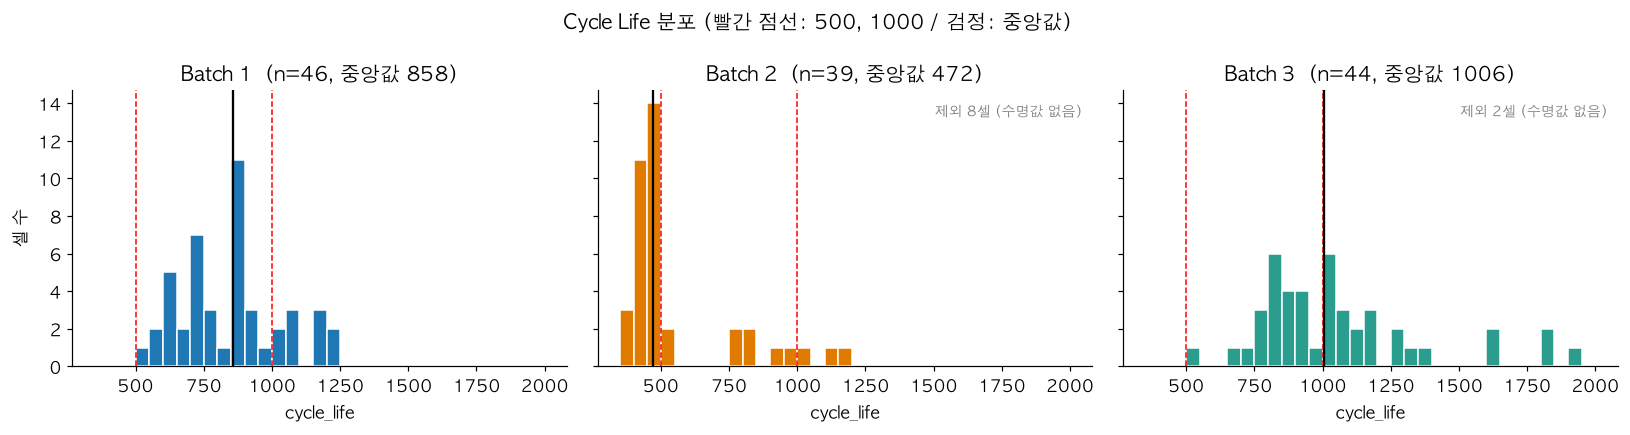

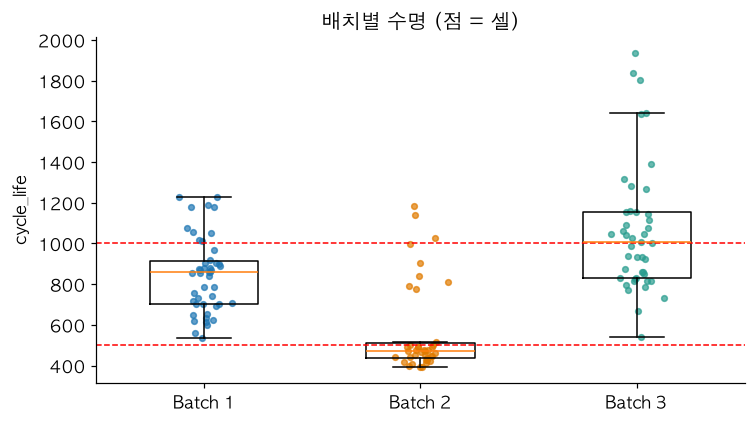

In [3]:
# Q1-b. 배치별 수명 분포 (히스토그램, 같은 축/구간으로 비교)
bins = np.arange(350, 2050, 50)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, b in zip(axes, valid):
    s = ct.loc[ct.batch == b, "cycle_life"]
    ax.hist(s, bins=bins, color=BATCH_COLOR[b], edgecolor="white")
    ax.axvline(500, color="red", ls="--", lw=1); ax.axvline(1000, color="red", ls="--", lw=1)
    ax.axvline(s.median(), color="black", lw=1.5)
    ax.set_title(f"{BATCH_NAME[b]}  (n={len(s)}, 중앙값 {s.median():.0f})")
    ax.set_xlabel("cycle_life")
    cens = excluded[(excluded.batch == b)]
    if len(cens):
        ax.text(0.98, 0.95, f"제외 {len(cens)}셀 (수명값 없음)", transform=ax.transAxes, ha="right", va="top", fontsize=9, color="gray")
axes[0].set_ylabel("셀 수")
fig.suptitle("Cycle Life 분포 (빨간 점선: 500, 1000 / 검정: 중앙값)")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q1_hist_by_batch.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
data = [ct.loc[ct.batch == b, "cycle_life"] for b in valid]
ax.boxplot(data, tick_labels=[BATCH_NAME[b] for b in valid], showfliers=False, widths=0.5)
for i, (b, s) in enumerate(zip(valid, data), start=1):
    ax.scatter(np.random.default_rng(SEED).normal(i, 0.06, len(s)), s, s=14, color=BATCH_COLOR[b], alpha=.7)
ax.axhline(500, color="red", ls="--", lw=1); ax.axhline(1000, color="red", ls="--", lw=1)
ax.set_ylabel("cycle_life"); ax.set_title("배치별 수명 (점 = 셀)")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q1_box_by_batch.png", bbox_inches="tight"); plt.show()

In [4]:
# Q1-c. 이상치 셀 식별 (배치 내 Tukey 1.5*IQR 기준) + 어떤 충전 조건/신호인지
rows = []
for b in valid:
    s = ct.loc[ct.batch == b, "cycle_life"]
    q1, q3 = s.quantile(.25), s.quantile(.75); lo, hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    out = ct[(ct.batch == b) & ((ct.cycle_life < lo) | (ct.cycle_life > hi))].copy()
    out["fence"] = f"[{lo:.0f}, {hi:.0f}]"; out["type"] = np.where(out.cycle_life < lo, "짧음", "김")
    rows.append(out)
outliers = pd.concat(rows)
display(outliers[["batch", "cycle_life", "type", "fence", "policy", "c1", "switch_pct", "c2", "early_chargetime", "early_Tavg", "early_IR"]].round(2))

,batch,cycle_life,type,fence,policy,c1,switch_pct,c2,early_chargetime,early_Tavg,early_IR
cell_id,,,,,,,,,,,
batch2_c007,batch2,777.0,김,"[336, 612]",4.8C(80%)-4.8C-newstructure,4.8,80.0,4.8,10.04,33.77,0.01
batch2_c008,batch2,904.0,김,"[336, 612]",5.2C(58%)-4C-newstructure,5.2,58.0,4.0,10.04,33.60,0.02
batch2_c009,batch2,791.0,김,"[336, 612]",5.6C(26%)-4.5C-newstructure,5.6,26.0,4.5,10.04,32.35,0.02
batch2_c032,batch2,809.0,김,"[336, 612]",4.8C(80%)-4.8C-newstructure,4.8,80.0,4.8,49.67,32.17,0.01
batch2_c033,batch2,1140.0,김,"[336, 612]",5.2C(58%)-4C-newstructure,5.2,58.0,4.0,10.04,32.74,0.01
batch2_c034,batch2,1186.0,김,"[336, 612]",5.6C(26%)-4.5C-newstructure,5.6,26.0,4.5,49.68,35.67,0.01
batch2_c043,batch2,1029.0,김,"[336, 612]",4.8C(80%)-4.8C-newstructure,4.8,80.0,4.8,10.04,33.93,0.00
batch2_c044,batch2,841.0,김,"[336, 612]",5.2C(58%)-4C-newstructure,5.2,58.0,4.0,49.66,33.96,0.00
batch2_c045,batch2,997.0,김,"[336, 612]",5.6C(26%)-4.5C-newstructure,5.6,26.0,4.5,10.04,35.27,0.00


In [5]:
# Q1-d. 왜 유독 짧은가: 배치별 하위 5셀 vs 나머지의 충전 조건/초기 신호 비교
rows = []
for b in valid:
    d = ct[ct.batch == b].sort_values("cycle_life")
    low, rest = d.head(5), d.iloc[5:]
    for col in ["c1", "c2", "switch_pct", "early_chargetime", "early_Tavg", "early_IR"]:
        rows.append({"batch": BATCH_NAME[b], "feature": col, "하위5 평균": low[col].mean(), "나머지 평균": rest[col].mean()})
cmp = pd.DataFrame(rows)
cmp["차이(%)"] = ((cmp["하위5 평균"] / cmp["나머지 평균"] - 1) * 100).round(1)
display(cmp.round(3))
print("하위 5셀 정책:")
for b in valid:
    d = ct[ct.batch == b].sort_values("cycle_life").head(5)
    print(f"  {BATCH_NAME[b]}:", list(zip(d.policy, d.cycle_life.astype(int))))

,batch,feature,하위5 평균,나머지 평균,차이(%)
0,Batch 1,c1,6.760,5.771,17.1
1,Batch 1,c2,4.320,3.493,23.7
2,Batch 1,switch_pct,54.000,51.220,5.4
3,Batch 1,early_chargetime,9.753,11.467,-15.0
4,Batch 1,early_Tavg,32.908,32.581,1.0
5,Batch 1,early_IR,0.016,0.017,-3.1
6,Batch 2,c1,4.960,5.041,-1.6
7,Batch 2,c2,4.100,4.637,-11.6
8,Batch 2,switch_pct,32.800,52.647,-37.7
9,Batch 2,early_chargetime,18.106,20.636,-12.3


하위 5셀 정책:
  Batch 1: [('5.4C(80%)-5.4C', 534), ('5.4C(80%)-5.4C', 559), ('8C(35%)-3.6C', 599), ('8C(35%)-3.6C', 616), ('7C(40%)-3.6C', 617)]
  Batch 2: [('6C(60%)-3C', 392), ('3.6C(9%)-5C', 393), ('3.6C(9%)-5C', 396), ('6C(60%)-3C', 408), ('5.6C(26%)-4.5C', 412)]
  Batch 3: [('3.7C(31%)-5.9C-newstructure', 541), ('3.7C(31%)-5.9C-newstructure', 667), ('5.9C(60%)-3.1C-newstructure', 731), ('3.7C(31%)-5.9C-newstructure', 772), ('5.6C(36%)-4.3C-newstructure', 786)]


In [6]:
# Q1-e. 제외된 셀 (수명값 없음) - 분포에서 빠진 이유
display(excluded)

,cell_id,batch,policy,n_cycles,reason
0,batch2_c022,batch2,VarCharge-2C-100cycles,920,cycle_life 없음(NaN): 수명 종료 미도달 또는 특수 실험 셀
1,batch2_c023,batch2,VarCharge-4C-100cycles,1152,cycle_life 없음(NaN): 수명 종료 미도달 또는 특수 실험 셀
2,batch2_c035,batch2,VarCharge-6C-100cycles,423,cycle_life 없음(NaN): 수명 종료 미도달 또는 특수 실험 셀
3,batch2_c036,batch2,VarCharge-8C-100cycles,280,cycle_life 없음(NaN): 수명 종료 미도달 또는 특수 실험 셀
4,batch2_c037,batch2,3.6C(80%)-3.6C(SLOWCYCLE,101,cycle_life 없음(NaN): 수명 종료 미도달 또는 특수 실험 셀
5,batch2_c038,batch2,4.8C(80%)-4.8C(SLOWCYCLE,101,cycle_life 없음(NaN): 수명 종료 미도달 또는 특수 실험 셀
6,batch2_c039,batch2,3.6C(9%)-5C(SLOWCYCLE,434,cycle_life 없음(NaN): 수명 종료 미도달 또는 특수 실험 셀
7,batch2_c040,batch2,5.2C(58%)-4C(SLOWCYCLE,459,cycle_life 없음(NaN): 수명 종료 미도달 또는 특수 실험 셀
8,batch3_c023,batch3,4.8C(80%)-4.8C-newstructure,2189,cycle_life 없음(NaN): 수명 종료 미도달 또는 특수 실험 셀
9,batch3_c032,batch3,4.8C(80%)-4.8C-newstructure,2237,cycle_life 없음(NaN): 수명 종료 미도달 또는 특수 실험 셀


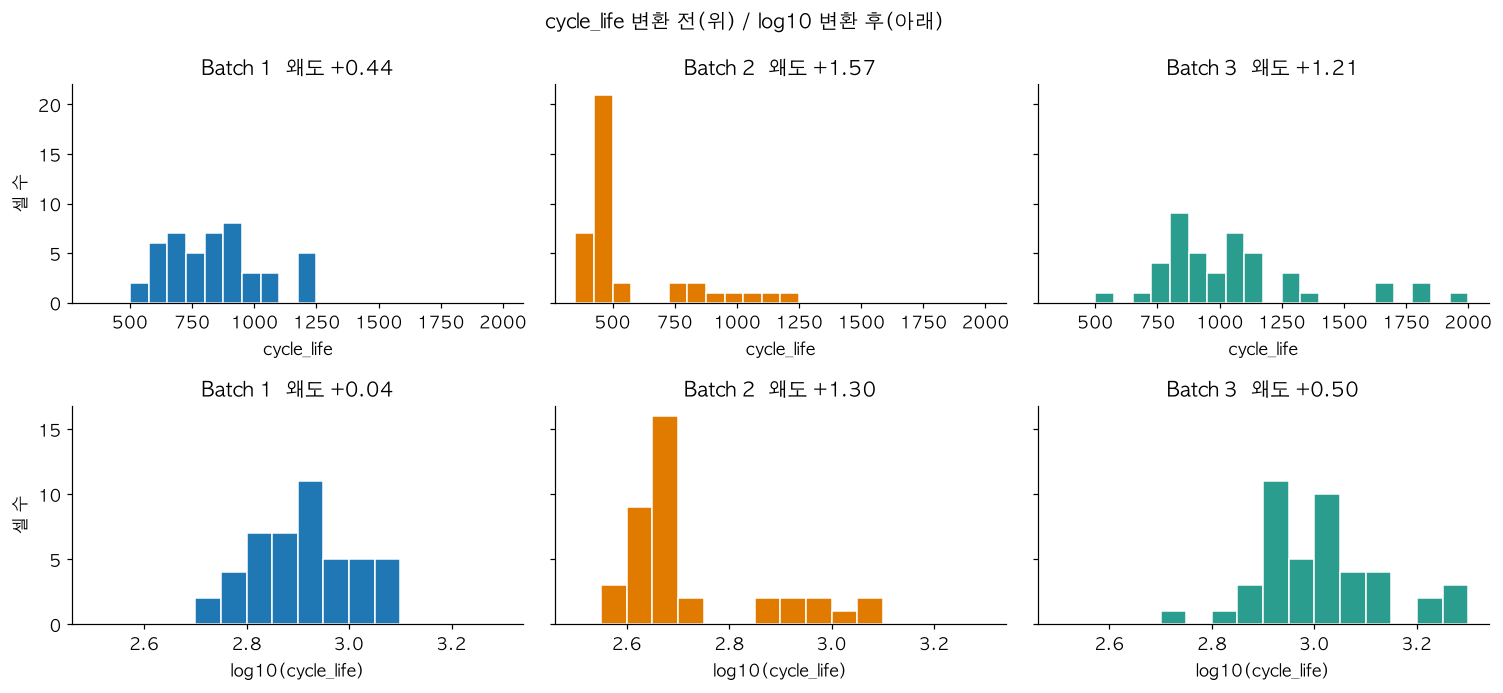

,n,왜도(원래),왜도(log10),Shapiro p(원래),Shapiro p(log10)
구분,,,,,
Batch 1,46,0.438,0.038,0.064,0.302
Batch 2,39,1.573,1.304,0.000,0.000
Batch 3,44,1.212,0.500,0.000,0.105
전체 129셀,129,0.887,-0.087,0.000,0.001


In [7]:
from scipy import stats
# Q1-f. 예측 대상(cycle_life)의 분포: 원래 값 vs log10 변환 후 (왜도/정규성 비교)
ct["log10_life"] = np.log10(ct["cycle_life"])
fig, axes = plt.subplots(2, 3, figsize=(14, 6.4), sharey="row")
rows = []
for j, b in enumerate(valid):
    d = ct[ct.batch == b]
    for i, (col, ttl, bins) in enumerate([("cycle_life", "cycle_life", np.arange(350, 2050, 75)), ("log10_life", "log10(cycle_life)", np.linspace(2.5, 3.3, 17))]):
        ax = axes[i, j]; ax.hist(d[col], bins=bins, color=BATCH_COLOR[b], edgecolor="white")
        ax.set_title(f"{BATCH_NAME[b]}  왜도 {stats.skew(d[col]):+.2f}"); ax.set_xlabel(ttl)
        if j == 0: ax.set_ylabel("셀 수")
    rows.append({"구분": BATCH_NAME[b], "n": len(d), "왜도(원래)": stats.skew(d.cycle_life), "왜도(log10)": stats.skew(d.log10_life),
                 "Shapiro p(원래)": stats.shapiro(d.cycle_life)[1], "Shapiro p(log10)": stats.shapiro(d.log10_life)[1]})
rows.append({"구분": "전체 129셀", "n": len(ct), "왜도(원래)": stats.skew(ct.cycle_life), "왜도(log10)": stats.skew(ct.log10_life),
             "Shapiro p(원래)": stats.shapiro(ct.cycle_life)[1], "Shapiro p(log10)": stats.shapiro(ct.log10_life)[1]})
fig.suptitle("cycle_life 변환 전(위) / log10 변환 후(아래)")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q1_log_transform.png", bbox_inches="tight"); plt.show()
display(pd.DataFrame(rows).set_index("구분").round(3))

### Q1 정리 (초안: 숫자는 위 표/그림 기준, 해석은 확인 필요)
**발견**
- **F1-1 배치마다 분포가 크게 다르다.** 중앙값 Batch 1 = 858, Batch 2 = 472, Batch 3 = 1006. Batch 2는 39셀 중 28셀(71.8%)이 500 미만이고, Batch 1·3에는 500 미만이 0셀이다.
- **F1-2 Batch 2는 2개 집단이다.** 392~514(30셀)와 777~1186(9셀). 후자 9셀은 모두 정책명에 `-newstructure`가 붙은 셀이고, 배치 내 이상치(Tukey)로 잡힌 셀과 정확히 일치한다. (`newstructure`의 의미는 데이터에 설명이 없어 가설 단계)
- **F1-3 Batch 3은 장수명 쪽 꼬리가 길다.** 541~1935, >1000이 52.3%, 이상치 3셀(1801~1935). Batch 1은 이상치 없음.
- **F1-4 같은 충전 정책이어도 배치가 다르면 수명이 다르다.** `4.8C(80%)-4.8C`: Batch 1 평균 753 / Batch 2 484 / Batch 2(newstructure) 872 / Batch 3 1564. `6C(60%)-3C`: Batch 1 744 / Batch 2 400. (셀 수 2~6개로 적어 경향 수준)
- **F1-5 짧은 셀의 원인은 배치에 따라 다르다.** Batch 1 하위 5셀은 고속 정책(5.4C(80%)-5.4C, 8C(35%)-3.6C, 7C(40%)-3.6C)이고 1단계 C-rate가 나머지보다 17% 높다. Batch 2는 하위 5셀과 나머지의 C-rate 차이가 거의 없어(1단계 -1.6%) 충전 조건으로 설명되지 않는다.
- **F1-6 수명이 없는 셀 10개가 분포에서 빠졌다.** Batch 2의 8셀(VarCharge 4, SLOWCYCLE 4)은 수명값이 없고, Batch 3의 2셀은 2189, 2237 사이클에도 수명이 끝나지 않았다(유효 셀 최대 1935보다 길다). 그래서 Batch 3의 장수명 쪽 꼬리는 실제보다 잘려 있다. 노션에 적힌 150~2,300 범위는 재현되지 않고(유효 392~1935), 2,300 근처는 이 미도달 셀들에 해당하는 것으로 보인다.

**해석**
- 배치 간 차이는 충전 조건보다 셀 자체(제조 시기/구조 등)의 영향이 더 커 보인다. 같은 정책이 배치마다 다른 수명을 낸다.
- Batch 2의 짧은 수명은 Batch 1로 학습한 모델이 보지 못한 구간(534 미만)이다. 유효 39셀 중 30셀(76.9%)이 해당한다.

**시사점 -> 모델링 반영**
- S1: Batch 1(534~1227)로 학습해 Batch 2(주로 392~514)를 예측해야 하므로 **학습 범위 밖 외삽**이 필요하다 -> 외삽이 가능한 선형 계열(Ridge/Elastic Net)을 우선하고, 트리 계열은 한계를 명시한 비교군으로 둔다.
- S2: 550 기준 Classification은 Batch 1에서 단수명이 1셀뿐이고 Batch 2는 30셀이라 학습/평가가 성립하지 않는다 -> **Regression 선택**의 근거.
- S3: 충전 정책만으로는 수명을 예측할 수 없다 -> 셀의 초기 전기화학 신호(ΔQ(V) 등)가 필요하다 (Q3로 연결).
- S4: 배치마다 범위 차이가 크고 Batch 3은 우측으로 치우친다 -> Target은 log10(cycle_life), 평가는 MAPE.
- S5: 제외 규칙(수명값 없음 10셀, 사유 표)을 코드와 문서에 명시한다. Batch 3은 장수명 꼬리가 잘려 있음을 주석으로 남긴다.
- S6: Batch 2의 newstructure 9셀은 별개 하위 집단으로 보이므로, DAY 2 오류 분석에서 이 집단의 오차를 따로 확인한다.

## Q2. 열화 곡선

- [ ] 사이클별 Qd 추이
- [ ] 열화 속도 일정/가속 여부
- [ ] Knee point 탐색

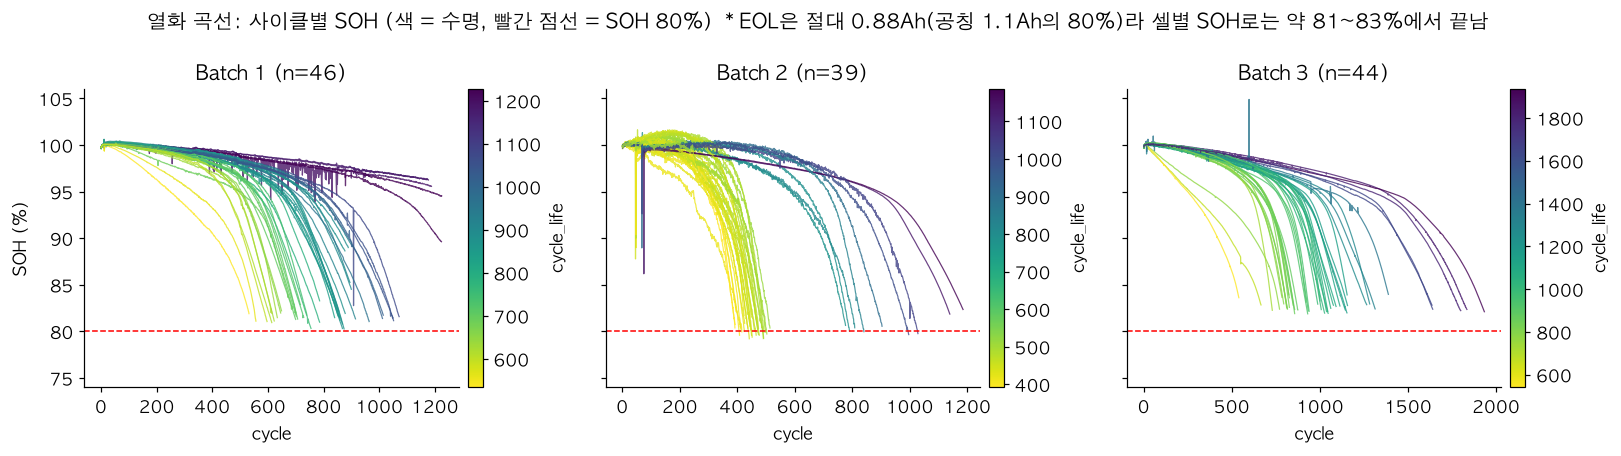

In [8]:
# Q2-a. SOH 곡선 만들기 (SOH = QD / 초기 공칭용량 x 100). 배치마다 공칭용량이 달라(1.07~1.10Ah) 비율로 비교한다.
def soh_curve(c):
    qd = c["summary"]["QD"]
    nominal = qd.iloc[:10].median()
    L = min(int(c["cycle_life"]), len(qd))          # 수명 종료 시점까지만 사용 (Batch 2는 EOL 이후에도 데이터가 이어짐)
    return (qd.iloc[:L] / nominal * 100)

soh = {cid: soh_curve(c) for v in valid.values() for cid, c in v.items()}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, b in zip(axes, valid):
    ids = ct.index[ct.batch == b]
    life = ct.loc[ids, "cycle_life"]
    norm = plt.Normalize(life.min(), life.max()); cmap = plt.cm.viridis_r
    for cid in ids:
        s = soh[cid]; ax.plot(s.index, s.values, color=cmap(norm(life[cid])), lw=.8, alpha=.8)
    ax.axhline(80, color="red", ls="--", lw=1)
    ax.set_title(f"{BATCH_NAME[b]} (n={len(ids)})"); ax.set_xlabel("cycle"); ax.set_ylim(74, 106)
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="cycle_life", pad=.02)
axes[0].set_ylabel("SOH (%)")
fig.suptitle("열화 곡선: 사이클별 SOH (색 = 수명, 빨간 점선 = SOH 80%)  * EOL은 절대 0.88Ah(공칭 1.1Ah의 80%)라 셀별 SOH로는 약 81~83%에서 끝남")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q2_soh_by_batch.png", bbox_inches="tight"); plt.show()

,early(0~30%),mid(30~70%),late(70~100%),late/early
batch,,,,
batch1,0.29,0.80,5.93,17.79
batch2,-0.07,1.79,10.67,-15.35
batch3,0.32,0.61,4.41,13.71


late > early 인 셀 비율(%): {'batch1': 100.0, 'batch2': 100.0, 'batch3': 100.0}


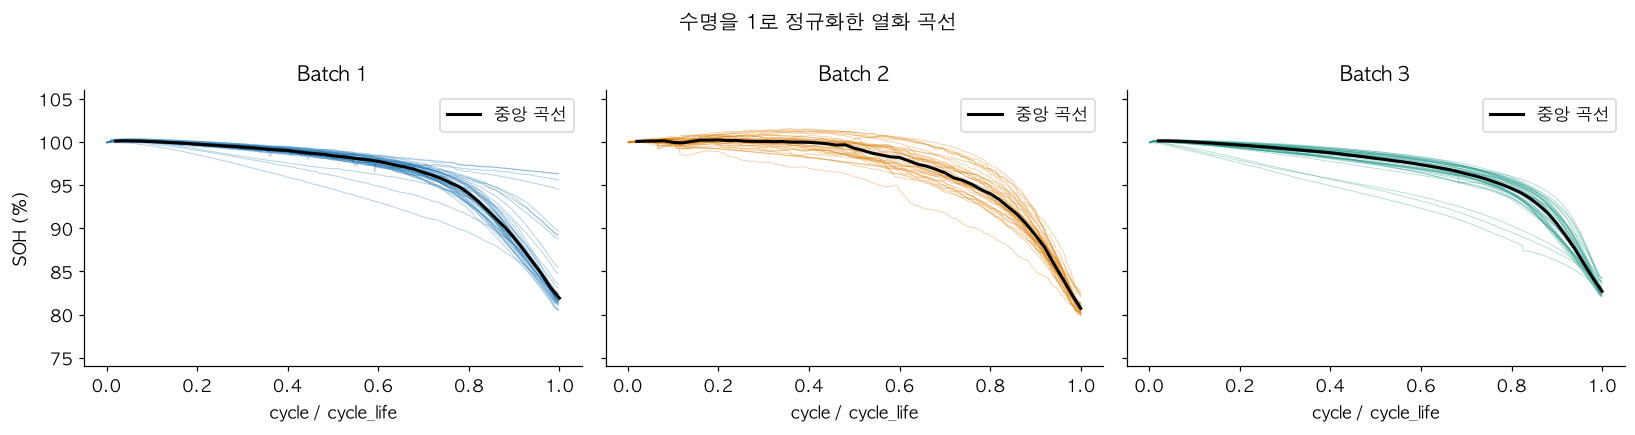

In [9]:
# Q2-b. 열화 속도는 일정한가, 가속되는가?  수명을 0~1로 정규화해 곡선 모양을 비교하고, 수명 구간별 열화 속도를 계산
def window_rates(s, life):
    """수명 앞 30% / 중간 40% / 뒤 30% 구간의 SOH 감소 속도 (%p / 100 cycles, 양수 = 감소)."""
    x = s.index.values.astype(float); y = s.rolling(11, center=True, min_periods=3).median().values
    out = {}
    for name, (a, b_) in {"early(0~30%)": (0, .3), "mid(30~70%)": (.3, .7), "late(70~100%)": (.7, 1.0)}.items():
        m = (x >= a * life) & (x <= b_ * life) & ~np.isnan(y)
        out[name] = -np.polyfit(x[m], y[m], 1)[0] * 100
    return out

rates = pd.DataFrame({cid: window_rates(soh[cid], ct.loc[cid, "cycle_life"]) for cid in ct.index}).T.join(ct[["batch"]])
rates["late/early"] = rates["late(70~100%)"] / rates["early(0~30%)"]
display(rates.groupby("batch")[["early(0~30%)", "mid(30~70%)", "late(70~100%)", "late/early"]].median().round(2))
print("late > early 인 셀 비율(%):", (rates.groupby("batch").apply(lambda d: (d["late(70~100%)"] > d["early(0~30%)"]).mean() * 100)).round(0).to_dict())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
grid = np.linspace(0.02, 1.0, 50)
for ax, b in zip(axes, valid):
    ids = ct.index[ct.batch == b]; curves = []
    for cid in ids:
        s = soh[cid].rolling(11, center=True, min_periods=3).median(); x = s.index.values / ct.loc[cid, "cycle_life"]
        ax.plot(x, s.values, color=BATCH_COLOR[b], lw=.6, alpha=.35); curves.append(np.interp(grid, x, s.values))
    ax.plot(grid, np.nanmedian(curves, axis=0), color="black", lw=2, label="중앙 곡선")
    ax.set_title(BATCH_NAME[b]); ax.set_xlabel("cycle / cycle_life"); ax.set_ylim(74, 106); ax.legend()
axes[0].set_ylabel("SOH (%)")
fig.suptitle("수명을 1로 정규화한 열화 곡선")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q2_soh_normalized.png", bbox_inches="tight"); plt.show()

,n_total,n_knee,knee_cycle_median,knee_frac_median,slope_before_median,slope_after_median
batch,,,,,,
batch1,46,43,626.0,0.75,-0.64,-6.79
batch2,39,39,341.0,0.74,-0.92,-12.05
batch3,44,43,821.0,0.80,-0.56,-6.47


knee 시점이 100사이클 이전인 셀 수: 0 / 129
knee_cycle vs cycle_life Spearman: {'batch1': 0.98, 'batch2': 0.93, 'batch3': 0.98}


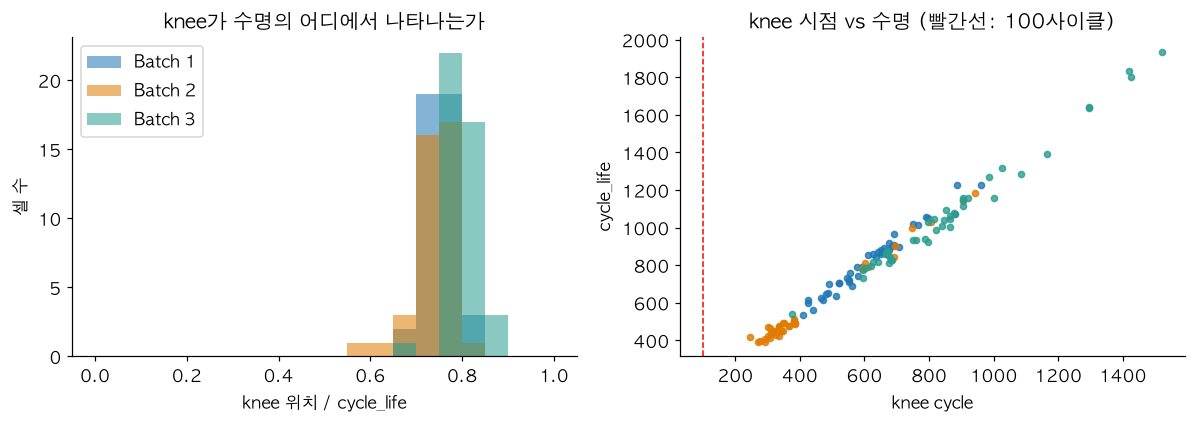

In [10]:
# Q2-c. Knee point 탐색: SOH를 2구간 연속 선형(hinge)으로 근사해 꺾이는 지점을 찾는다 (이후 기울기가 앞의 2배 이상 가팔라지면 knee로 판정)
def find_knee(s, step=5):
    y = s.rolling(11, center=True, min_periods=3).median(); x = y.index.values.astype(float); y = y.values
    m = ~np.isnan(y); x, y = x[m], y[m]
    best = None
    for k in range(int(x[0]) + 30, int(x[-1]) - 30, step):
        X = np.c_[np.ones_like(x), x, np.maximum(0, x - k)]
        coef, *_ = np.linalg.lstsq(X, y, rcond=None); sse = ((X @ coef - y) ** 2).sum()
        if best is None or sse < best[0]: best = (sse, k, coef[1], coef[1] + coef[2])
    _, k, s1, s2 = best
    return {"knee_cycle": k, "slope_before": s1 * 100, "slope_after": s2 * 100}

knees = pd.DataFrame({cid: find_knee(soh[cid]) for cid in ct.index}).T.join(ct[["batch", "cycle_life"]]).astype({"knee_cycle": float, "slope_before": float, "slope_after": float})
knees["knee_frac"] = knees["knee_cycle"] / knees["cycle_life"]
knees["has_knee"] = (knees["slope_after"] < 2 * knees["slope_before"]) & (knees["slope_after"] < -0.5)   # 이후 2배 이상 가파르고 100사이클당 0.5%p 이상 감소
kn = knees[knees["has_knee"]]   # knee가 검출된 셀만으로 위치/시점을 요약
summary = kn.groupby("batch").agg(n=("has_knee", "size"), knee_cycle_median=("knee_cycle", "median"),
                                    knee_frac_median=("knee_frac", "median"), slope_before_median=("slope_before", "median"),
                                    slope_after_median=("slope_after", "median"))
summary.insert(0, "n_total", knees.groupby("batch").size()); summary = summary.rename(columns={"n": "n_knee"})
display(summary.round(2))
print("knee 시점이 100사이클 이전인 셀 수:", int((knees["knee_cycle"] < 100).sum()), "/", len(knees))
print("knee_cycle vs cycle_life Spearman:", kn.groupby("batch").apply(lambda d: d["knee_cycle"].corr(d["cycle_life"], method="spearman")).round(2).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for b in valid:
    d = kn[kn.batch == b]
    axes[0].hist(d["knee_frac"], bins=np.linspace(0, 1, 21), alpha=.55, color=BATCH_COLOR[b], label=BATCH_NAME[b])
    axes[1].scatter(d["knee_cycle"], d["cycle_life"], s=16, color=BATCH_COLOR[b], alpha=.8, label=BATCH_NAME[b])
axes[0].set_xlabel("knee 위치 / cycle_life"); axes[0].set_ylabel("셀 수"); axes[0].legend(); axes[0].set_title("knee가 수명의 어디에서 나타나는가")
axes[1].set_xlabel("knee cycle"); axes[1].set_ylabel("cycle_life"); axes[1].axvline(100, color="red", ls="--", lw=1); axes[1].set_title("knee 시점 vs 수명 (빨간선: 100사이클)")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q2_knee.png", bbox_inches="tight"); plt.show()

,early_change 중앙값(%p),min,max,Spearman vs 수명
batch,,,,
batch1,0.025,-1.257,0.394,0.563
batch2,0.155,-1.799,1.176,-0.209
batch3,0.032,-1.780,0.203,-0.025


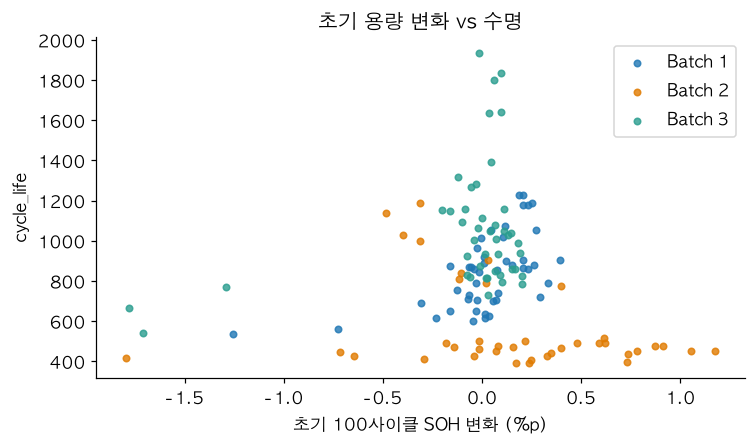

In [11]:
# Q2-d. 초기 100사이클의 용량 변화만으로 수명을 구분할 수 있는가?  (초기 SOH 변화 = cycle 96~100 중앙값 - cycle 2~6 중앙값)
def early_change(c):
    qd = c["summary"]["QD"]
    return (qd.loc[96:100].median() - qd.loc[2:6].median()) / qd.iloc[:10].median() * 100
ct["early_soh_change"] = [early_change(valid[ct.loc[cid, "batch"]][cid]) for cid in ct.index]
display(ct.groupby("batch").apply(lambda d: pd.Series({"early_change 중앙값(%p)": d["early_soh_change"].median(),
                                                       "min": d["early_soh_change"].min(), "max": d["early_soh_change"].max(),
                                                       "Spearman vs 수명": d["early_soh_change"].corr(d["cycle_life"], method="spearman")})).round(3))
fig, ax = plt.subplots(figsize=(7, 4.2))
for b in valid:
    d = ct[ct.batch == b]; ax.scatter(d["early_soh_change"], d["cycle_life"], s=18, color=BATCH_COLOR[b], alpha=.8, label=BATCH_NAME[b])
ax.set_xlabel("초기 100사이클 SOH 변화 (%p)"); ax.set_ylabel("cycle_life"); ax.legend(); ax.set_title("초기 용량 변화 vs 수명")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q2_early_change.png", bbox_inches="tight"); plt.show()

### Q2 정리 (초안: 숫자는 위 표/그림 기준, 해석은 확인 필요)
**발견**
- **F2-1 곡선 모양은 3개 배치가 같다.** 수명을 1로 정규화하면 곡선이 거의 겹친다: 오래 완만하다가 뒤에서 급락한다.
- **F2-2 열화는 일정하지 않고 가속된다.** 수명 구간별 SOH 감소 속도(%p/100사이클, 중앙값) 앞 30% -> 중간 -> 뒤 30%: Batch 1 0.29 -> 0.80 -> 5.93, Batch 2 -0.07 -> 1.79 -> 10.67, Batch 3 0.32 -> 0.61 -> 4.41. 모든 셀(129/129)에서 뒤쪽이 앞쪽보다 빠르다. Batch 2는 초반에 SOH가 오히려 소폭 오른다(-0.07).
- **F2-3 knee는 수명의 약 75~80% 지점에 있다.** 검출 43/46, 39/39, 43/44셀. 위치(수명 대비) 0.75 / 0.74 / 0.80, knee 이후 기울기는 이전의 약 10배(-0.64 -> -6.79, -0.92 -> -12.05, -0.56 -> -6.47 %p/100사이클). knee 시점과 수명의 Spearman 상관은 0.98 / 0.93 / 0.98.
- **F2-4 knee는 초기 100사이클 안에 한 번도 나타나지 않는다(0/129).** 초기 100사이클은 수명의 약 10~21%(Batch 1 12%, Batch 2 21%, Batch 3 10%)이며 전부 knee 이전의 완만한 구간이다.
- **F2-5 초기 용량 변화만으로는 수명을 구분하지 못한다.** 초기 100사이클 SOH 변화와 수명의 Spearman 상관이 +0.56 / -0.21 / -0.03으로 배치마다 방향이 다르다. 대부분 셀이 +-0.5%p 안에 몰려 있다.
- **F2-6 Batch 1의 9셀(19.6%)은 수명이 기록된 시점의 마지막 관측 SOH가 85.6~96.3%다.** 80% 도달이 실제로 관측되지 않았으므로 이 셀들의 cycle_life는 추정값일 가능성이 있다(가설). 수명 1177~1227인 5셀(3.6C(80%)-3.6C 3셀, 4C(80%)-4C 2셀)이 특히 그렇고, knee가 검출되지 않은 Batch 1의 3셀이 이 3.6C 셀들이다.
- **F2-7 EOL 기준은 절대 0.88Ah(공칭 1.1Ah의 80%)로 보인다.** 셀 자신의 초기 용량 대비 SOH로는 Batch 2가 약 81%, Batch 3이 약 83%에서 끝난다 (Batch 2는 수명 판정이 39/39셀에서 QD<=0.88Ah 최초 시점과 일치).
- (데이터 품질) 방전용량(QD)에는 스파이크가 일부 남아 있다(Batch 3의 약 115% 1점, Batch 1·2의 하향 스파이크). 곡선 분석은 이동 중앙값(11사이클)으로 완화했다.

**해석**
- 셀마다 수명이 다를 뿐 열화의 형태는 같고, 수명을 결정하는 것은 뒤쪽 가속(knee) 이후다. 그런데 knee는 수명의 75~80% 지점이라 초기 100사이클에서는 관측할 수 없다.
- 따라서 초기 구간에서는 용량(QD) 자체가 아니라 용량이 전압 구간별로 어떻게 달라지는지(ΔQ(V))처럼 더 미세한 신호에서 수명을 예측해야 한다.

**시사점 -> 모델링 반영**
- S7: QD 기반 초기 요약(변화량, 기울기)은 배치마다 방향이 달라(F2-5, 앞서 확인한 부호 불일치) 단독 핵심 피처로 쓰지 않는다 -> **ΔQ(V) 기반 피처를 중심**으로 한다 (Q3에서 검증).
- S8: 곡선 모양이 같고 시간 축 스케일만 다르므로 수명의 차이는 곱셈적이다 -> Target **log10(cycle_life)** 선택을 뒷받침한다.
- S9: Batch 1의 9셀은 라벨(수명)이 추정일 가능성이 있다 -> 학습/평가에서 큰 오차가 날 수 있으므로 DAY 2 오류 분석에서 따로 확인하고 README 한계로 명시한다.
- S10: QD 스파이크가 남아 있으므로 요약 통계는 평균 대신 중앙값 같은 강건한 방식을 쓰고, 스파이크 처리 규칙(현재 공칭의 1.2배 초과)은 DAY 2 전처리에서 보강 여부를 검토한다.

## Q3. ΔQ(V) 곡선

- [ ] Q(V) cycle100 - cycle10
- [ ] 장수명 vs 단수명 ΔQ 형태 비교
- [ ] 구분 가능한 통계값 피처 추출

Vdlin: 2.0 ~ 3.5 V, 1000 점 | ΔQ NaN 개수: 0 | 평균 부호(음수 비율): 0.93


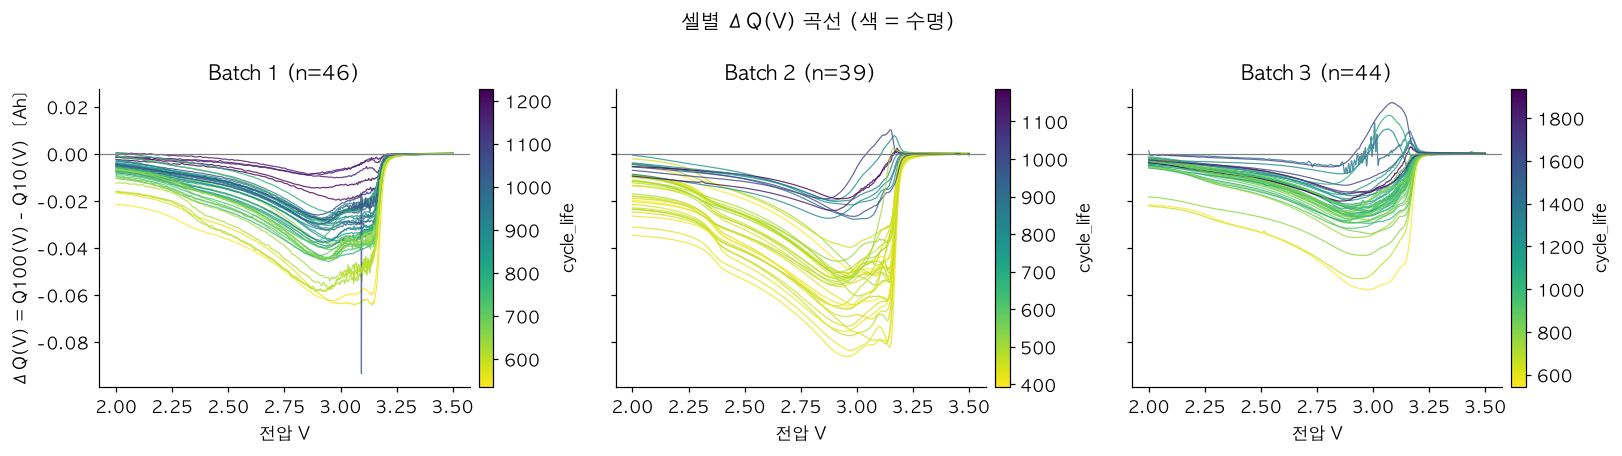

In [12]:
# Q3-a. ΔQ(V) = Q_discharge(V)|cycle 100 - Q_discharge(V)|cycle 10  (Qdlin: 전압 2.0~3.5V를 1000점으로 보간한 방전용량)
from scipy import stats
LO, HI = DQ_CYCLE_LO, DQ_CYCLE_HI        # 10, 100  (Qdlin_early[k-1] = k번째 사이클)
cells_valid = {cid: c for v in valid.values() for cid, c in v.items()}
V = next(iter(cells_valid.values()))["Vdlin"]
assert all(np.allclose(c["Vdlin"], V) for c in cells_valid.values()), "Vdlin 격자가 셀마다 다름"
DQ = pd.DataFrame({cid: c["Qdlin_early"][HI - 1] - c["Qdlin_early"][LO - 1] for cid, c in cells_valid.items()}, index=V).T
print("Vdlin:", V.min(), "~", V.max(), "V,", len(V), "점 | ΔQ NaN 개수:", int(DQ.isna().sum().sum()), "| 평균 부호(음수 비율):", round(float((DQ < 0).mean().mean()), 2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, b in zip(axes, valid):
    ids = ct.index[ct.batch == b]; life = ct.loc[ids, "cycle_life"]
    norm = plt.Normalize(life.min(), life.max()); cmap = plt.cm.viridis_r
    for cid in ids: ax.plot(V, DQ.loc[cid], color=cmap(norm(life[cid])), lw=.8, alpha=.8)
    ax.axhline(0, color="gray", lw=.8); ax.set_title(f"{BATCH_NAME[b]} (n={len(ids)})"); ax.set_xlabel("전압 V")
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="cycle_life", pad=.02)
axes[0].set_ylabel("ΔQ(V) = Q100(V) - Q10(V)  [Ah]")
fig.suptitle("셀별 ΔQ(V) 곡선 (색 = 수명)")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q3_dq_curves.png", bbox_inches="tight"); plt.show()

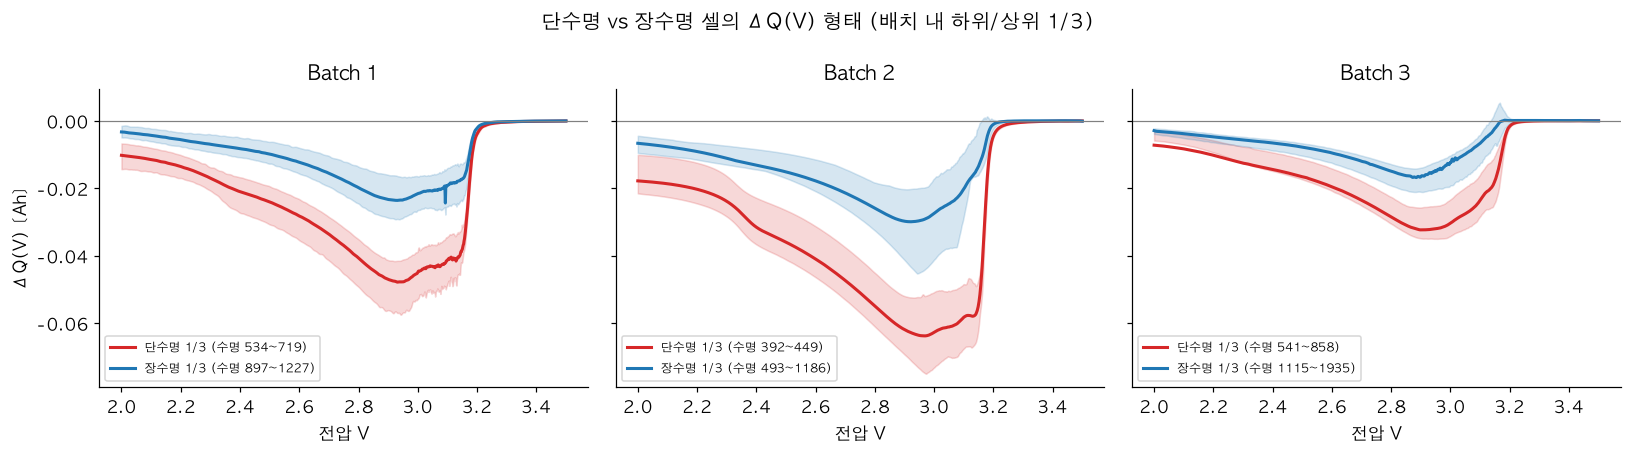

In [13]:
# Q3-b. 장수명 vs 단수명: 배치 내 하위/상위 1/3 셀의 평균 ΔQ(V) 곡선 비교 (음영 = 그룹 내 25~75%)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, b in zip(axes, valid):
    d = ct[ct.batch == b].sort_values("cycle_life"); k = len(d) // 3
    for name, ids, col in [("단수명 1/3", d.index[:k], "#d62728"), ("장수명 1/3", d.index[-k:], "#1f77b4")]:
        g = DQ.loc[ids]; ax.plot(V, g.mean(), color=col, lw=2, label=f"{name} (수명 {int(d.loc[ids, 'cycle_life'].min())}~{int(d.loc[ids, 'cycle_life'].max())})")
        ax.fill_between(V, g.quantile(.25), g.quantile(.75), color=col, alpha=.18)
    ax.axhline(0, color="gray", lw=.8); ax.set_title(BATCH_NAME[b]); ax.set_xlabel("전압 V"); ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("ΔQ(V) [Ah]")
fig.suptitle("단수명 vs 장수명 셀의 ΔQ(V) 형태 (배치 내 하위/상위 1/3)")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q3_dq_short_vs_long.png", bbox_inches="tight"); plt.show()

In [14]:
# Q3-c. ΔQ(V)를 구분 가능한 통계값으로 요약 -> 수명과의 관계 (로그 변환: var, |min|, |mean| 은 log10)
def dq_features(row):
    x = row.values
    return {"log10_var": np.log10(np.nanvar(x)), "log10_abs_min": np.log10(abs(np.nanmin(x))), "log10_abs_mean": np.log10(abs(np.nanmean(x))),
            "skew": stats.skew(x, nan_policy="omit"), "kurtosis": stats.kurtosis(x, nan_policy="omit"),
            "abs_max": np.nanmax(np.abs(x)), "range": np.nanmax(x) - np.nanmin(x), "auc": np.trapezoid(x, V)}
F = pd.DataFrame({cid: dq_features(DQ.loc[cid]) for cid in DQ.index}).T.join(ct[["batch", "cycle_life"]])
F["log10_life"] = np.log10(F["cycle_life"])
feat_cols = ["log10_var", "log10_abs_min", "log10_abs_mean", "skew", "kurtosis", "abs_max", "range", "auc"]

rows = []
for f in feat_cols:
    r = {"feature": f}
    for b in list(valid) + ["all"]:
        d = F if b == "all" else F[F.batch == b]
        r[f"{b} Spearman"] = stats.spearmanr(d[f], d["log10_life"])[0]
    # 단수명/장수명(배치 내 하위/상위 1/3) 구분력: AUC (0.5 = 구분 못함, 1 또는 0 = 완전 구분)
    aucs = []
    for b in valid:
        d = F[F.batch == b].sort_values("cycle_life"); k = len(d) // 3
        lo, hi = d[f].iloc[:k], d[f].iloc[-k:]
        aucs.append(stats.mannwhitneyu(hi, lo)[0] / (len(hi) * len(lo)))
    r["AUC(장 vs 단) b1/b2/b3"] = " / ".join(f"{a:.2f}" for a in aucs)
    rows.append(r)
corr_tbl = pd.DataFrame(rows).set_index("feature")
corr_tbl["|Spearman| 평균"] = corr_tbl[[f"{b} Spearman" for b in valid]].abs().mean(axis=1)
display(corr_tbl.sort_values("|Spearman| 평균", ascending=False).round(2))
print("배치 간 부호 일관성(3개 배치 Spearman 부호가 모두 같은가):",
      {f: bool(np.sign(corr_tbl.loc[f, [f"{b} Spearman" for b in valid]]).nunique() == 1) for f in feat_cols})

,batch1 Spearman,batch2 Spearman,batch3 Spearman,all Spearman,AUC(장 vs 단) b1/b2/b3,|Spearman| 평균
feature,,,,,,
log10_var,-0.85,-0.71,-0.80,-0.89,0.02 / 0.05 / 0.04,0.79
log10_abs_mean,-0.83,-0.70,-0.76,-0.87,0.05 / 0.04 / 0.06,0.76
auc,-0.83,-0.70,-0.76,-0.87,0.05 / 0.04 / 0.06,0.76
log10_abs_min,-0.77,-0.66,-0.78,-0.86,0.09 / 0.07 / 0.05,0.74
abs_max,-0.77,-0.66,-0.77,-0.86,0.09 / 0.07 / 0.05,0.73
range,-0.77,-0.65,-0.67,-0.84,0.09 / 0.07 / 0.10,0.70
kurtosis,0.31,0.50,0.32,0.40,0.74 / 0.82 / 0.77,0.38
skew,-0.57,-0.15,0.06,-0.34,0.17 / 0.36 / 0.58,0.26


배치 간 부호 일관성(3개 배치 Spearman 부호가 모두 같은가): {'log10_var': True, 'log10_abs_min': True, 'log10_abs_mean': True, 'skew': False, 'kurtosis': True, 'abs_max': True, 'range': True, 'auc': True}


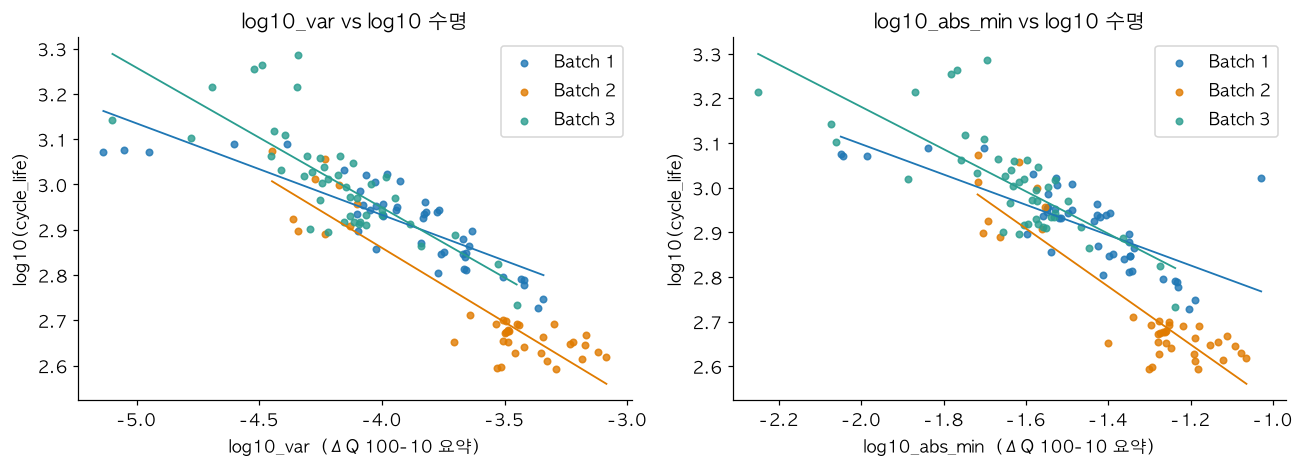

,feature,batch,slope,intercept,Pearson r,n
0,log10_var,Batch 1,-0.202,2.124,-0.846,46
1,log10_var,Batch 2,-0.328,1.547,-0.918,39
2,log10_var,Batch 3,-0.309,1.712,-0.762,44
3,log10_abs_min,Batch 1,-0.339,2.418,-0.740,46
4,log10_abs_min,Batch 2,-0.649,1.869,-0.901,39
5,log10_abs_min,Batch 3,-0.473,2.234,-0.744,44


In [15]:
# Q3-d. 가장 강한 피처 vs 수명 (로그-로그), 배치별 직선 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
fit_rows = []
for ax, f in zip(axes, ["log10_var", "log10_abs_min"]):
    for b in valid:
        d = F[F.batch == b]; ax.scatter(d[f], d["log10_life"], s=18, color=BATCH_COLOR[b], alpha=.8, label=BATCH_NAME[b])
        slope, icpt = np.polyfit(d[f], d["log10_life"], 1); xs = np.linspace(d[f].min(), d[f].max(), 20)
        ax.plot(xs, slope * xs + icpt, color=BATCH_COLOR[b], lw=1.2)
        fit_rows.append({"feature": f, "batch": BATCH_NAME[b], "slope": slope, "intercept": icpt, "Pearson r": d[f].corr(d["log10_life"]), "n": len(d)})
    ax.set_xlabel(f"{f}  (ΔQ 100-10 요약)"); ax.set_ylabel("log10(cycle_life)"); ax.set_title(f"{f} vs log10 수명"); ax.legend()
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q3_feature_vs_life.png", bbox_inches="tight"); plt.show()
display(pd.DataFrame(fit_rows).round(3))

### Q3 정리 (초안: 숫자는 위 표/그림 기준, 해석은 확인 필요)
**발견**
- **F3-1 ΔQ(V) 곡선의 모양은 3개 배치가 같다.** 값의 93%가 음수이고, 가장 깊게 꺼지는 전압은 약 2.93V(중앙값, IQR 2.91~2.96V), 3.2V 부근에서 0으로 수렴한다.
- **F3-2 수명이 짧은 셀일수록 ΔQ가 깊게 꺼진다.** 배치 내 하위/상위 1/3의 평균 최소 ΔQ(Ah): Batch 1 -0.048 vs -0.028, Batch 2 -0.065 vs -0.032, Batch 3 -0.033 vs -0.017 (단수명 vs 장수명). 3개 배치 모두에서 같은 방향이다. 즉 초기 100사이클 동안 2.9V 부근의 방전용량이 크게 줄어든 셀이 먼저 수명을 다한다.
- **F3-3 장수명 일부 셀은 3.1V 부근에서 ΔQ가 양수로 올라간다.** Batch 2는 4/39셀, Batch 3은 8/44셀이고 거의 모두 장수명 1/3에 속한다(단수명 1/3은 0셀). Batch 1은 0/46.
- **F3-4 log10(분산(ΔQ))이 가장 강하고 배치 간 일관된 신호다.** 수명과의 Spearman -0.85 / -0.71 / -0.80 (전체 -0.89), Pearson(log10 수명) -0.85 / -0.92 / -0.76. 배치 내 장수명 셀의 값이 단수명 셀보다 작은 쌍의 비율이 98% / 95% / 96%다. log10|평균|, log10|최소|, 최대 절대값, 범위도 비슷하게 강하다(-0.65~-0.83). 첨도는 약한 양의 상관(+0.31 / +0.50 / +0.32)이고, **왜도는 배치마다 부호가 다르다**(-0.57 / -0.15 / +0.06).
- **F3-5 요약 통계끼리 거의 같은 정보다.** log10_var - log10|min| 0.95, log10_var - log10|mean| 0.93, log10|min| - log10|mean| 0.96. AUC(전압 적분)는 평균에 상수배라 사실상 동일하다.
- **F3-6 같은 피처 값이어도 배치마다 수명이 다르다.** log10_var -> log10 수명 직선의 기울기/절편: Batch 1 -0.20/2.12, Batch 2 -0.33/1.55, Batch 3 -0.31/1.71. log10_var = -3.5에서 직선이 가리키는 수명은 Batch 1 약 679, Batch 3 약 622, Batch 2 약 494로, Batch 2가 Batch 1보다 약 27% 짧다.
- **F3-7 최솟값 계열은 스파이크에 민감하다.** Batch 1의 한 셀은 3.1V 부근에 -0.09Ah 스파이크가 있어 log10|min| 산점도에서 이상점이 되고, Batch 3의 한 셀은 곡선이 톱니처럼 흔들린다. 분산/평균은 상대적으로 영향이 작다. ΔQ 계산에 쓴 Qdlin에는 결측이 없다.

**해석**
- ΔQ(V)는 "초기 100사이클 사이에 용량이 전압 구간별로 얼마나 줄었는가"를 보여주고, 그 크기(특히 2.9V 부근의 깊이)가 이후 수명을 가르는 신호로 보인다. Q2에서 확인한 대로 용량(QD) 자체는 초기에 차이가 없었던 것과 대비된다.
- 로그-로그 관계가 거의 직선이라 선형 계열 모델이 자연스럽다. 다만 직선의 절편이 배치마다 달라, 한 배치에서 맞춘 직선이 다른 배치에는 한쪽으로 치우쳐 적용될 수 있다.

**시사점 -> 모델링 반영**
- S11: 핵심 피처(FE1)는 ΔQ(V) 요약 통계로 하고, **log10(분산)을 중심**으로 log10|평균|(또는 |최소|), 첨도를 보조로 검토한다. 왜도는 배치 간 부호가 달라 제외한다.
- S12: 요약 통계끼리 상관이 0.93~0.96이므로 모두 넣으면 다중공선성이 생긴다 -> 피처를 2~3개로 줄이거나 정규화 선형 모델(Ridge/Elastic Net)을 쓴다 (Q5에서 VIF로 확정).
- S13: 로그-로그 선형 관계가 강하다 -> 선형 계열 후보의 근거. Target log10과 일관된다(S8).
- S14: 배치마다 절편이 달라 Batch 1로 학습한 모델이 Batch 2에서 수명을 **체계적으로 과대예측**할 가능성이 있다 (이는 EDA 수준의 예상이며 실제 성능은 DAY 2에서 확인) -> Gap(Valid-Test) 해석과 오류 분석에서 편향과 분산을 구분한다.
- S15: 극값 통계(최솟값)는 스파이크에 민감하므로 분산/평균 같은 강건한 통계를 우선한다.

## Q4. 충전 조건(C-rate)과 수명

- [ ] 프로토콜별 평균 수명
- [ ] 고속 충전 셀이 정말 짧은가
- [ ] 충전 전류 패턴-열화 속도 상관

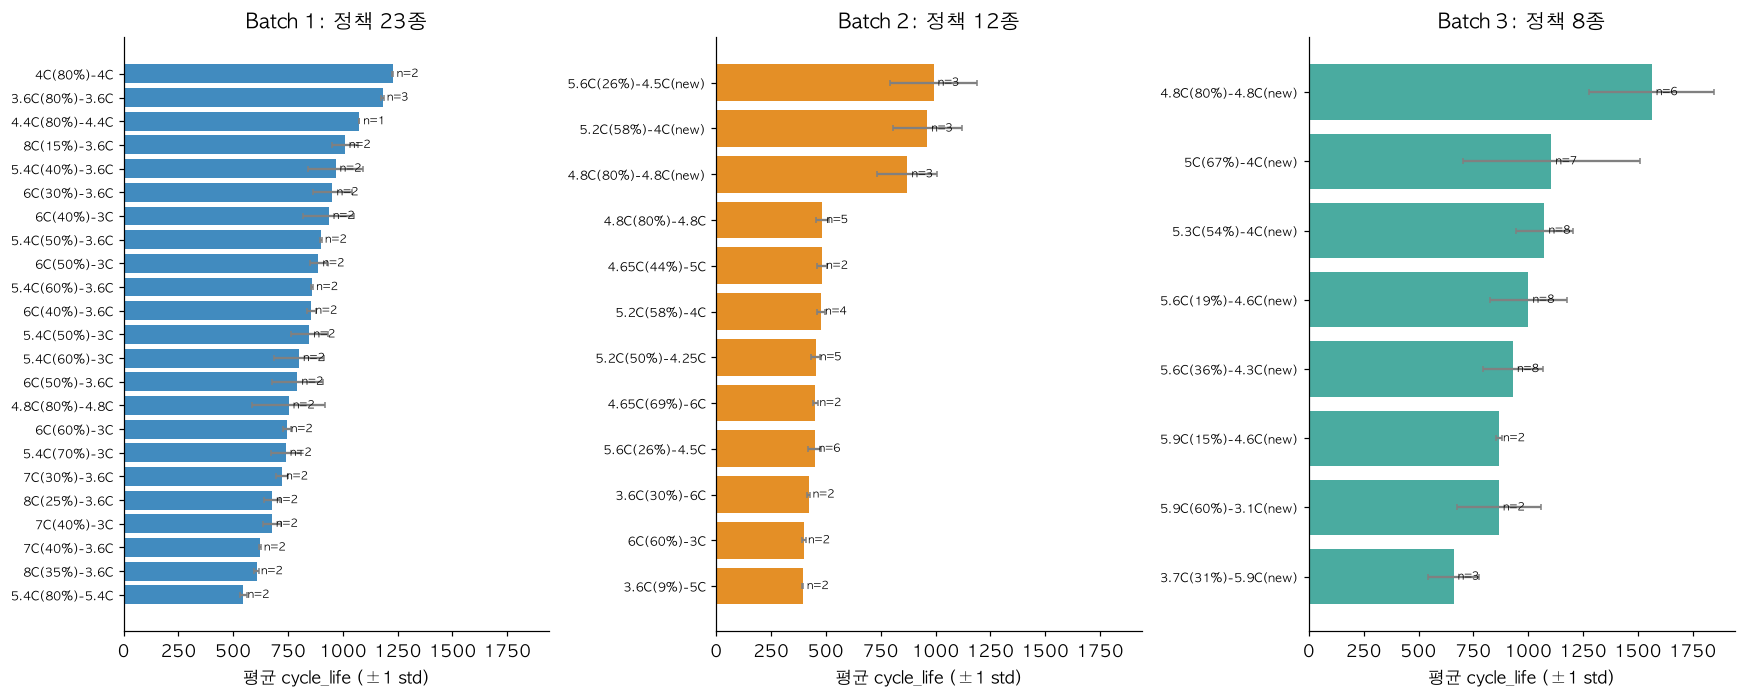

          min      max  ratio
batch                        
batch1  546.5  1226.50   2.24
batch2  394.5   991.33   2.51
batch3  660.0  1564.17   2.37


In [16]:
# Q4-a. 충전 프로토콜(정책)별 평균 수명.  정책명 `C1(S%)-C2` = 1단계 C1으로 S%까지, 이후 C2로 충전
ct["policy_short"] = ct.policy.str.replace("-newstructure", "(new)", regex=False)
pol = ct.groupby(["batch", "policy_short"]).cycle_life.agg(["mean", "std", "count"]).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 6.5), sharex=True)
for ax, b in zip(axes, valid):
    d = pol[pol.batch == b].sort_values("mean")
    ax.barh(d.policy_short, d["mean"], xerr=d["std"].fillna(0), color=BATCH_COLOR[b], alpha=.85, error_kw=dict(ecolor="gray", capsize=2))
    for y, (m, n) in enumerate(zip(d["mean"], d["count"])): ax.text(m + 20, y, f"n={n}", va="center", fontsize=7)
    ax.set_title(f"{BATCH_NAME[b]}: 정책 {len(d)}종"); ax.set_xlabel("평균 cycle_life (±1 std)"); ax.tick_params(axis="y", labelsize=8)
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q4_life_by_policy.png", bbox_inches="tight"); plt.show()
print(pol.groupby("batch")["mean"].agg(["min", "max"]).assign(ratio=lambda d: d["max"] / d["min"]).round(2).to_string())

In [17]:
# Q4-b. 충전 속도 지표 만들기. 평균 C-rate = 80% 충전까지의 평균 속도 = 80 / (S/C1 + (80-S)/C2)  (S: 전환 지점 %)
q4 = ct[["batch", "policy", "cycle_life", "c1", "c2", "switch_pct"]].copy()
q4["avg_c"] = 80 / (q4.switch_pct / q4.c1 + (80 - q4.switch_pct).clip(lower=0) / q4.c2)
q4["log10_life"] = np.log10(q4.cycle_life)
# 초기 사이클(2~100) 중앙값 신호 (평균은 소수 스파이크에 흔들려 중앙값 사용)
sig = {cid: c["summary"].loc[2:100, ["chargetime", "Tavg", "Tmax"]].median() for cid, c in cells_valid.items()}
q4 = q4.join(pd.DataFrame(sig).T.add_prefix("early_"))
# 열화 속도: 수명의 20~60% 구간(knee 이전)의 SOH 감소 속도 (%p/100사이클). 값이 클수록 빨리 열화
def mid_rate(cid):
    s = soh[cid]; L = ct.loc[cid, "cycle_life"]; m = (s.index >= .2 * L) & (s.index <= .6 * L) & s.notna()
    return -np.polyfit(s.index[m], s[m], 1)[0] * 100
q4["rate_mid"] = [mid_rate(cid) for cid in q4.index]
print("avg_c 범위 (배치별):", q4.groupby("batch").avg_c.agg(["min", "max"]).round(2).to_dict("index"))
print("정책에서 유도한 평균 C-rate와 실제 측정 충전시간(early_chargetime)의 Spearman:",
      q4.groupby("batch").apply(lambda d: d["avg_c"].corr(d["early_chargetime"], method="spearman")).round(2).to_dict())

# 배치 효과를 빼고 보기: 배치 평균을 뺀 값(demeaned)으로 3개 배치를 합쳐 상관을 계산
def corr_table(target):
    feats = ["avg_c", "c1", "c2", "switch_pct", "early_chargetime", "early_Tavg", "early_Tmax"]
    rows = []
    for f in feats:
        r = {"feature": f}
        for b in valid: d = q4[q4.batch == b]; r[BATCH_NAME[b]] = d[f].corr(d[target], method="spearman")
        dm = q4[[f, target]] - q4.groupby("batch")[[f, target]].transform("mean")
        r["합산(배치평균 제거)"] = dm[f].corr(dm[target], method="spearman")
        r["합산(배치효과 포함)"] = q4[f].corr(q4[target], method="spearman")
        rows.append(r)
    return pd.DataFrame(rows).set_index("feature")
print("[수명(log10)과의 Spearman]"); display(corr_table("log10_life").round(2))
print("[열화 속도(rate_mid)와의 Spearman]"); display(corr_table("rate_mid").round(2))

avg_c 범위 (배치별): {'batch1': {'min': 3.6, 'max': 5.4}, 'batch2': {'min': 4.79, 'max': 4.81}, 'batch3': {'min': 4.79, 'max': 4.81}}
정책에서 유도한 평균 C-rate와 실제 측정 충전시간(early_chargetime)의 Spearman: {'batch1': -0.99, 'batch2': -0.19, 'batch3': -0.08}
[수명(log10)과의 Spearman]


,Batch 1,Batch 2,Batch 3,합산(배치평균 제거),합산(배치효과 포함)
feature,,,,,
avg_c,-0.63,0.35,-0.13,-0.19,-0.14
c1,-0.48,0.06,-0.23,-0.21,-0.03
c2,0.05,-0.12,0.02,-0.05,-0.15
switch_pct,0.19,0.29,0.44,0.27,0.16
early_chargetime,0.64,-0.81,0.26,0.22,-0.03
early_Tavg,-0.37,0.17,0.03,0.00,0.17
early_Tmax,-0.32,-0.14,-0.04,-0.13,-0.02


[열화 속도(rate_mid)와의 Spearman]


,Batch 1,Batch 2,Batch 3,합산(배치평균 제거),합산(배치효과 포함)
feature,,,,,
avg_c,0.52,0.05,0.10,0.18,0.06
c1,0.48,-0.33,0.28,0.02,0.08
c2,-0.11,0.69,0.21,0.36,0.28
switch_pct,-0.12,-0.26,-0.64,-0.30,-0.25
early_chargetime,-0.56,0.56,-0.24,-0.17,-0.00
early_Tavg,0.39,-0.20,0.21,0.09,-0.05
early_Tmax,0.36,-0.13,0.26,0.11,0.06


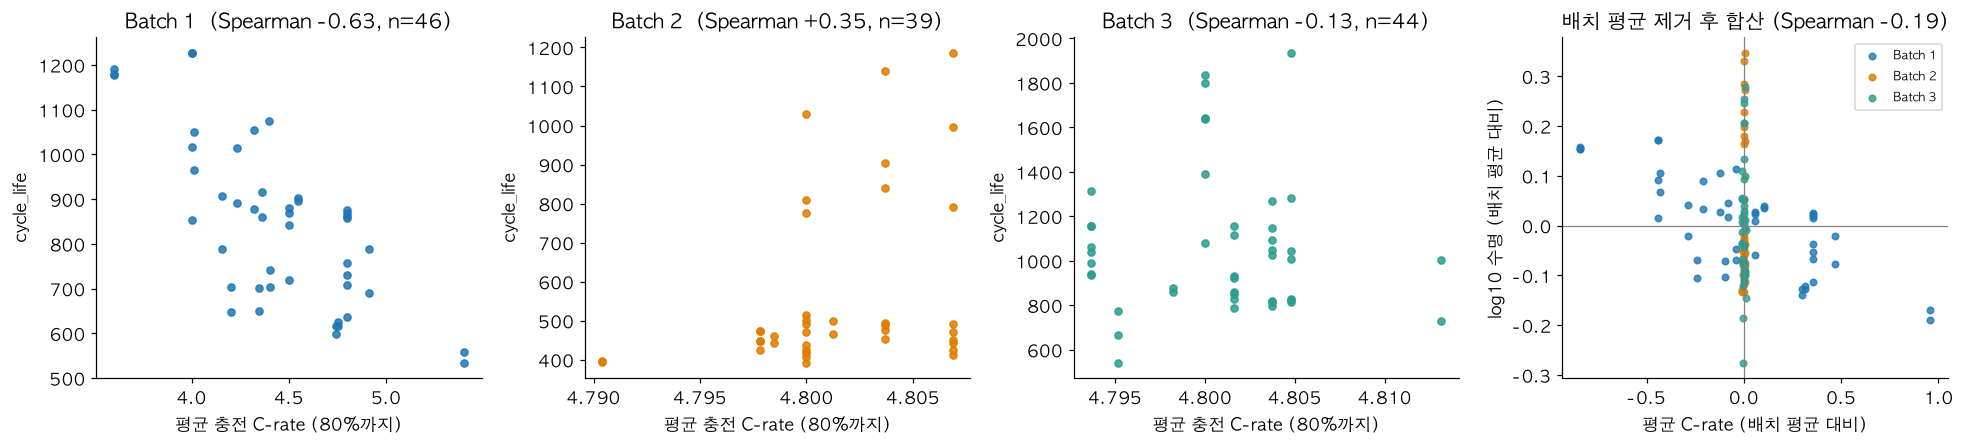

In [18]:
# Q4-c. 고속 충전 셀이 정말 수명이 짧은가?  평균 C-rate vs 수명 (배치별 + 배치 평균을 뺀 합산)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, b in zip(axes[:3], valid):
    d = q4[q4.batch == b]; ax.scatter(d.avg_c, d.cycle_life, s=22, color=BATCH_COLOR[b], alpha=.85)
    rho = d.avg_c.corr(d.cycle_life, method="spearman"); ax.set_title(f"{BATCH_NAME[b]}  (Spearman {rho:+.2f}, n={len(d)})")
    ax.set_xlabel("평균 충전 C-rate (80%까지)"); ax.set_ylabel("cycle_life")
dm = q4[["avg_c", "log10_life"]] - q4.groupby("batch")[["avg_c", "log10_life"]].transform("mean")
for b in valid: m = q4.batch == b; axes[3].scatter(dm.avg_c[m], dm.log10_life[m], s=18, color=BATCH_COLOR[b], alpha=.8, label=BATCH_NAME[b])
axes[3].axhline(0, color="gray", lw=.8); axes[3].axvline(0, color="gray", lw=.8)
axes[3].set_title(f"배치 평균 제거 후 합산 (Spearman {dm.avg_c.corr(dm.log10_life, method='spearman'):+.2f})")
axes[3].set_xlabel("평균 C-rate (배치 평균 대비)"); axes[3].set_ylabel("log10 수명 (배치 평균 대비)"); axes[3].legend(fontsize=8)
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q4_crate_vs_life.png", bbox_inches="tight"); plt.show()

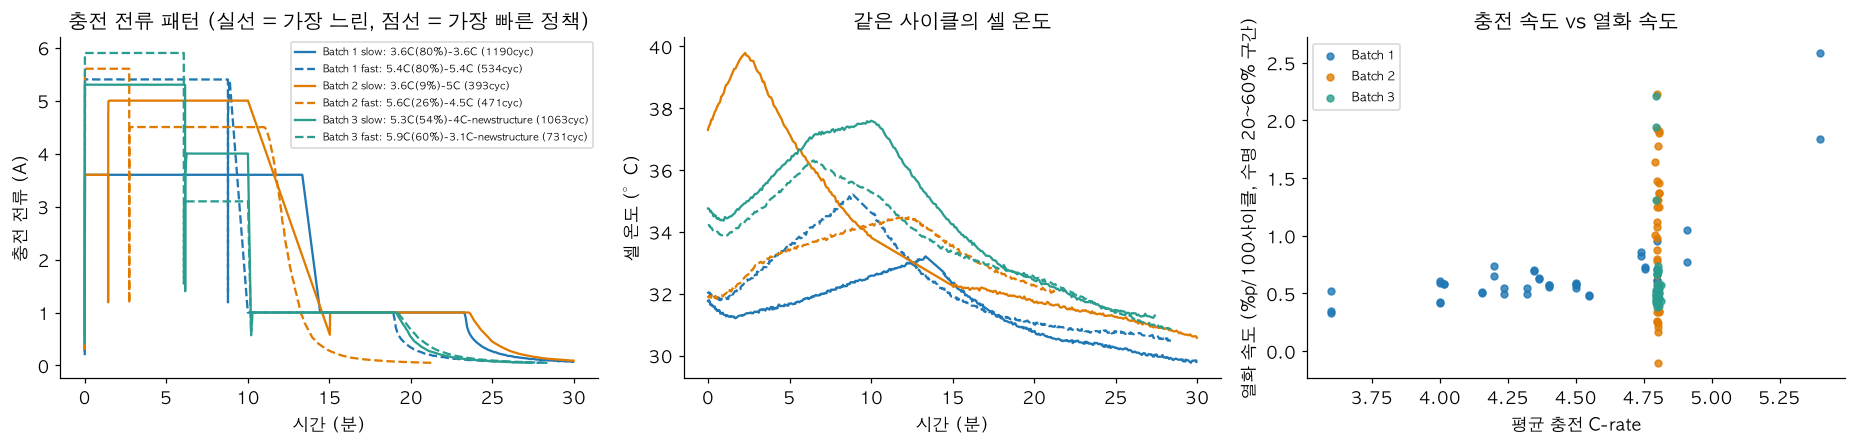

In [19]:
# Q4-d. 충전 전류 패턴 (10번째 사이클 실측)과 온도 -> 열화 속도.  배치별로 가장 느린/빠른 평균 C-rate 셀을 비교
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
styles = {"slow": "-", "fast": "--"}
for b in valid:
    d = q4[q4.batch == b].dropna(subset=["avg_c"]).sort_values("avg_c")
    for tag, cid in [("slow", d.index[0]), ("fast", d.index[-1])]:
        pr = cells_valid[cid]["profile10"]; m = (pr["I"] > 0.05) & (pr["t"] <= 30)
        lab = f"{BATCH_NAME[b]} {tag}: {q4.loc[cid, 'policy']} ({int(q4.loc[cid, 'cycle_life'])}cyc)"
        axes[0].plot(pr["t"][m], pr["I"][m], styles[tag], color=BATCH_COLOR[b], label=lab)
        axes[1].plot(pr["t"][m], pr["T"][m], styles[tag], color=BATCH_COLOR[b])
axes[0].set_xlabel("시간 (분)"); axes[0].set_ylabel("충전 전류 (A)"); axes[0].set_title("충전 전류 패턴 (실선 = 가장 느린, 점선 = 가장 빠른 정책)"); axes[0].legend(fontsize=6.5)
axes[1].set_xlabel("시간 (분)"); axes[1].set_ylabel("셀 온도 (°C)"); axes[1].set_title("같은 사이클의 셀 온도")
for b in valid:
    d = q4[q4.batch == b]; axes[2].scatter(d.avg_c, d.rate_mid, s=20, color=BATCH_COLOR[b], alpha=.8, label=BATCH_NAME[b])
axes[2].set_xlabel("평균 충전 C-rate"); axes[2].set_ylabel("열화 속도 (%p/100사이클, 수명 20~60% 구간)"); axes[2].set_title("충전 속도 vs 열화 속도"); axes[2].legend(fontsize=8)
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q4_current_pattern.png", bbox_inches="tight"); plt.show()

### Q4 정리 (초안: 숫자는 위 표/그림 기준, 해석은 확인 필요)
**발견**
- **F4-1 정책에 따라 배치 안에서 수명이 약 2.2~2.5배 달라진다.** 정책별 평균 수명의 최대/최소 비율은 Batch 1 2.24, Batch 2 2.51, Batch 3 2.37. Batch 1은 4C(80%)-4C(1227), 3.6C(80%)-3.6C(1183)가 가장 길고 5.4C(80%)-5.4C(547), 8C(35%)-3.6C(608)가 가장 짧다.
- **F4-2 같은 정책의 셀은 수명이 거의 같다.** 정책이 수명(log10)의 분산을 설명하는 비율이 Batch 1 92%, Batch 3 57%이고(Batch 2의 94%는 `-newstructure` 셀과 기존 셀이 별도 정책으로 분리된 효과가 크다), 정책 내 변동계수의 중앙값은 Batch 1 4.9%, Batch 2 4.7%, Batch 3 17.5%다.
- **F4-3 평균 충전 속도는 Batch 1에서만 달라진다.** 80%까지 충전하는 측정 시간이 Batch 1은 8.99~13.36분으로 다양하지만, Batch 2·3은 모든 정책이 약 10.0~10.2분으로 같다(평균 C-rate 4.79~4.81). 정책명에서 계산한 평균 C-rate와 실제 충전시간은 Batch 1에서 Spearman -0.99로 일치한다.
- **F4-4 고속 충전이 수명을 줄이는 경향은 Batch 1에서만 분명하다.** Batch 1에서 평균 C-rate와 수명의 Spearman -0.63, 열화 속도와는 +0.52. Batch 2·3은 속도가 사실상 같아 상관(+0.35, -0.13)이 의미가 없고, 배치 평균을 뺀 3개 배치 합산은 -0.19로 약하다.
- **F4-5 평균 속도가 같을 때는 전류가 어떤 모양으로 걸리는지가 열화와 관련 있어 보인다.** 2단계 C-rate(c2)가 클수록(합산 Spearman +0.36), 1단계에서 전환하는 지점이 이를수록(-0.30) 열화 속도가 빠르다(Batch 2의 c2 +0.69, Batch 3의 전환 지점 -0.64). 반면 수명 자체와의 상관은 약하다(c2 -0.05). 정책당 셀이 2~8개라 경향 수준이다.
- **F4-6 온도 신호는 배치 간 일관되지 않다.** 초기 Tavg/Tmax와 수명의 Spearman은 Batch 1 -0.37/-0.32, Batch 2 +0.17/-0.14, Batch 3 +0.03/-0.04, 합산 0.00/-0.13.
- **F4-7 측정 충전시간(chargetime)은 피처로 쓰면 안 된다.** 수명과의 상관 부호가 배치마다 반대(+0.64 / -0.81 / +0.26)이고, Batch 2의 -0.81은 `-newstructure` 셀(10.04분)과 기존 셀(10.17분)의 0.1분 차이가 구조 그룹을 구분하기 때문에 생긴 것으로 보인다(충전 효과가 아님). 일부 사이클에는 약 3,930분의 이상값도 있어 평균이 왜곡된다.

**해석**
- 충전 정책은 수명에 큰 영향을 주지만(정책 간 2배 이상) 평균 충전 속도 하나로는 설명되지 않는다. 배치마다 정책 설계가 달라(Batch 2·3은 10분 충전으로 통일) 속도 효과가 보이는 배치는 Batch 1뿐이다.
- Batch 1에서는 같은 정책의 셀이 사실상 같은 수명이라, 학습에 쓰는 독립 정보는 46셀이 아니라 약 23개 정책이다.

**시사점 -> 모델링 반영**
- S16: 정책 파라미터(c1, c2, 전환 지점)와 평균 C-rate는 배치 전체에서 일관된 강한 신호가 아니다(합산 |Spearman| 0.2~0.36) -> **약한 보조 후보**로만 두고, 핵심은 ΔQ(V)(S11)로 한다.
- S17: 측정 충전시간은 구조 그룹을 대신 구분하는 값이라 배치 의존적이다 -> **피처에서 제외**한다. 이상값이 있는 시간 변수는 평균 대신 중앙값을 쓴다.
- S18: Batch 2·3은 평균 충전 속도가 같아서, Batch 1로 학습한 "속도" 효과는 Test(Batch 2)에서 정보가 없다 -> 평균 C-rate 계열은 Test에서 도움이 되지 않을 가능성이 크다.
- S19: 같은 정책의 셀은 수명이 거의 같아(F4-2) 무작위로 나누면 같은 정책이 train/valid에 갈라져 **누수**가 생긴다 -> 분할은 **정책(셀 그룹) 단위**로 하고, 교차검증도 GroupKFold(정책)로 한다. 노션이 Valid를 셀 단위 Hold-out으로 두는 이유와도 일치한다.

## Q5. 상관관계

- [ ] 초기 사이클 피처와 cycle_life 상관계수
- [ ] 가장 강한 관계
- [ ] 다중공선성 확인(VIF/상관행렬)

In [20]:
# Q5-a. 초기 100사이클에서 만든 후보 피처 전체 (ΔQ(V) / 용량 / 내부저항 / 온도 / 충전 정책)
def early_feats(c):
    s = c["summary"]; qd, ir = s["QD"], s["IR"].replace(0, np.nan)
    x = np.arange(2, 101); ok = qd.loc[2:100].notna().values
    return {"qd_init": qd.loc[2:6].median(), "qd_slope": np.polyfit(x[ok], qd.loc[2:100].values[ok], 1)[0] * 100,   # Ah/100사이클
            "qd_change": qd.loc[96:100].median() - qd.loc[2:6].median(),
            "ir_init": ir.loc[2:6].median(), "ir_change": ir.loc[96:100].median() - ir.loc[2:6].median(),
            "Tavg": s["Tavg"].loc[2:100].median(), "Tmax": s["Tmax"].loc[2:100].median(), "chargetime": s["chargetime"].loc[2:100].median()}
E = pd.DataFrame({cid: early_feats(c) for cid, c in cells_valid.items()}).T
FT = F[["batch", "cycle_life", "log10_life", "log10_var", "log10_abs_min", "log10_abs_mean", "kurtosis", "skew"]].join(E).join(q4[["avg_c", "c1", "c2", "switch_pct"]])
GROUP = {"log10_var": "ΔQ(V)", "log10_abs_min": "ΔQ(V)", "log10_abs_mean": "ΔQ(V)", "kurtosis": "ΔQ(V)", "skew": "ΔQ(V)",
         "qd_init": "용량", "qd_slope": "용량", "qd_change": "용량", "ir_init": "내부저항", "ir_change": "내부저항",
         "Tavg": "온도", "Tmax": "온도", "chargetime": "충전", "avg_c": "정책", "c1": "정책", "c2": "정책", "switch_pct": "정책"}
FEATS = list(GROUP)
print("피처 수:", len(FEATS), "| 결측:", int(FT[FEATS].isna().sum().sum()), "| 셀 수:", len(FT))

rows = []
for f in FEATS:
    r = {"feature": f, "group": GROUP[f]}
    for b in valid: d = FT[FT.batch == b]; r[BATCH_NAME[b]] = d[f].corr(d["log10_life"], method="spearman")
    dm = FT[[f, "log10_life"]] - FT.groupby("batch")[[f, "log10_life"]].transform("mean")
    r["합산(배치평균 제거)"] = dm[f].corr(dm["log10_life"], method="spearman")
    rows.append(r)
CT = pd.DataFrame(rows).set_index("feature")
bcols = [BATCH_NAME[b] for b in valid]
CT["부호 일관"] = CT[bcols].apply(lambda r: bool(np.sign(r).nunique() == 1), axis=1)
CT["|ρ| 평균"] = CT[bcols].abs().mean(axis=1)
CT = CT.sort_values("|ρ| 평균", ascending=False)
display(CT.round(2))

피처 수: 17 | 결측: 12 | 셀 수: 129


,group,Batch 1,Batch 2,Batch 3,합산(배치평균 제거),부호 일관,|ρ| 평균
feature,,,,,,,
log10_var,ΔQ(V),-0.85,-0.71,-0.80,-0.83,True,0.79
log10_abs_mean,ΔQ(V),-0.83,-0.70,-0.76,-0.78,True,0.76
log10_abs_min,ΔQ(V),-0.77,-0.66,-0.78,-0.79,True,0.74
chargetime,충전,0.64,-0.81,0.26,0.22,False,0.57
kurtosis,ΔQ(V),0.31,0.50,0.32,0.23,True,0.38
avg_c,정책,-0.63,0.35,-0.13,-0.19,False,0.37
qd_slope,용량,0.58,-0.27,0.09,0.03,False,0.31
switch_pct,정책,0.19,0.29,0.44,0.27,True,0.31
qd_change,용량,0.57,-0.21,-0.03,0.07,False,0.27


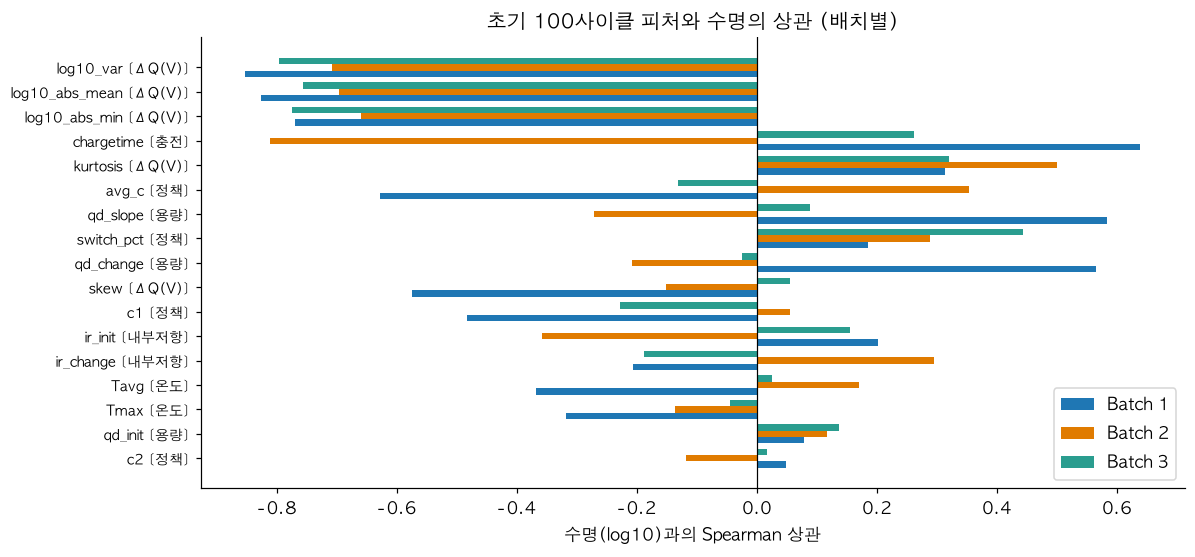

In [21]:
# Q5-b. 수명과의 상관 순위 (Spearman, 배치별) - 가장 강하고 일관된 신호는 무엇인가
fig, ax = plt.subplots(figsize=(11, 5.2))
order = CT.index[::-1]; h = 0.26
for k, b in enumerate(valid):
    ax.barh(np.arange(len(order)) + (k - 1) * h, CT.loc[order, BATCH_NAME[b]], height=h, color=BATCH_COLOR[b], label=BATCH_NAME[b])
ax.set_yticks(np.arange(len(order))); ax.set_yticklabels([f"{f} [{GROUP[f]}]" for f in order], fontsize=9)
ax.axvline(0, color="black", lw=.8); ax.set_xlabel("수명(log10)과의 Spearman 상관"); ax.legend(loc="lower right")
ax.set_title("초기 100사이클 피처와 수명의 상관 (배치별)")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q5_corr_with_life.png", bbox_inches="tight"); plt.show()

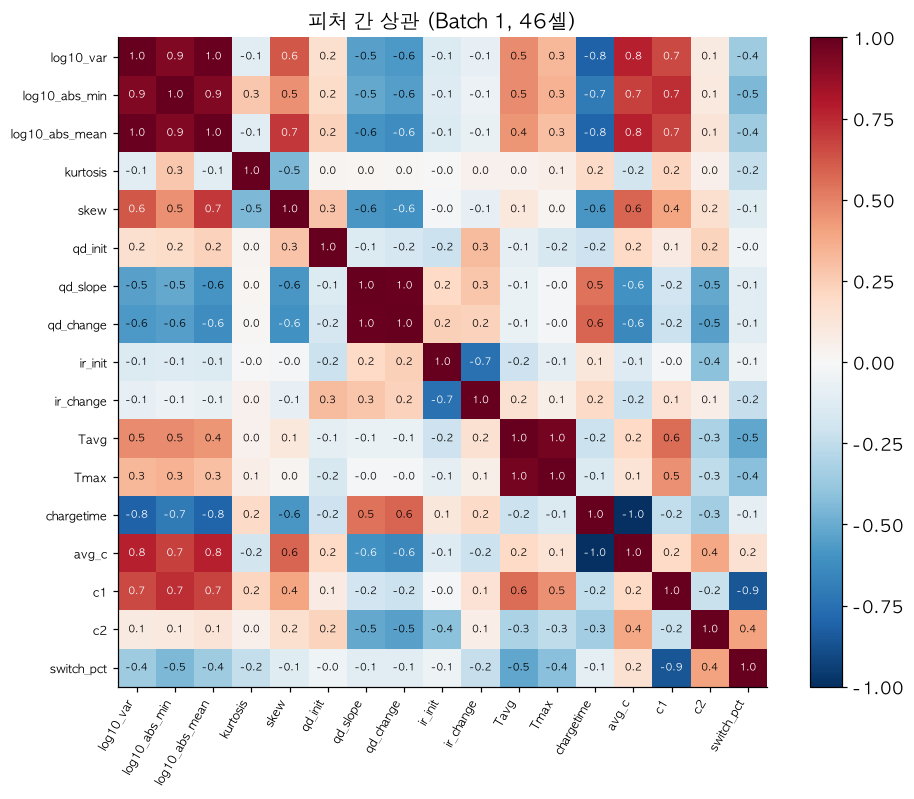

전체 후보 VIF (상위):


,VIF
log10_abs_min,2606.3
log10_abs_mean,1389.7
log10_var,658.7
chargetime,345.5
avg_c,326.8
kurtosis,303.3
qd_slope,88.1
qd_change,87.0


제거 순서 (피처, 제거 시점 VIF, 남은 피처 수): [('log10_abs_min', 2606.3, 16), ('log10_abs_mean', 418.1, 15), ('chargetime', 332.4, 14), ('qd_change', 79.6, 13), ('Tavg', 50.8, 12), ('c1', 12.6, 11), ('ir_change', 7.4, 10), ('avg_c', 6.8, 9)]
VIF < 5 로 남은 피처: ['log10_var', 'kurtosis', 'skew', 'qd_init', 'qd_slope', 'ir_init', 'Tmax', 'c2', 'switch_pct']


,VIF
log10_var,2.47
kurtosis,1.91
skew,3.47
qd_init,1.30
qd_slope,2.88
ir_init,1.37
Tmax,1.47
c2,2.12
switch_pct,2.00


In [22]:
# Q5-c. 다중공선성: Batch 1(학습 배치) 피처 간 상관행렬과 VIF.  VIF = 1/(1-R²), 5 초과면 다른 피처로 설명되는 중복
B1 = FT[FT.batch == "batch1"][FEATS]
fig, ax = plt.subplots(figsize=(9, 7.4))
cm_ = B1.corr(); im = ax.imshow(cm_, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATS))); ax.set_yticks(range(len(FEATS))); ax.set_xticklabels(FEATS, rotation=60, ha="right", fontsize=8); ax.set_yticklabels(FEATS, fontsize=8)
for i in range(len(FEATS)):
    for j in range(len(FEATS)):
        v = cm_.iloc[i, j]; ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6.5, color="white" if abs(v) > .6 else "black")
plt.colorbar(im, ax=ax, fraction=.046); ax.set_title("피처 간 상관 (Batch 1, 46셀)")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "q5_corr_heatmap.png", bbox_inches="tight"); plt.show()

def vif(df):
    Z = (df - df.mean()) / df.std(); out = {}
    for c in df.columns:
        y = Z[c].values; X = np.c_[np.ones(len(Z)), Z.drop(columns=c).values]
        beta, *_ = np.linalg.lstsq(X, y, rcond=None); r2 = 1 - ((y - X @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        out[c] = 1 / (1 - r2) if r2 < 1 - 1e-9 else np.inf
    return pd.Series(out)

cur = list(FEATS); path = []
print("전체 후보 VIF (상위):"); display(vif(B1[cur]).sort_values(ascending=False).head(8).round(1).to_frame("VIF"))
while True:
    v = vif(B1[cur]); cand = v.drop("log10_var", errors="ignore")      # 핵심 피처(log10_var)는 보호
    if v.max() < 5 or len(cur) <= 2: break
    drop = cand.idxmax(); path.append((drop, round(float(v[drop]), 1), len(cur) - 1)); cur.remove(drop)
print("제거 순서 (피처, 제거 시점 VIF, 남은 피처 수):", path)
print("VIF < 5 로 남은 피처:", cur)
display(vif(B1[cur]).round(2).to_frame("VIF"))

In [23]:
# Q5-d. 남은 피처가 배치 간 일관된 신호인가 + 선형으로 충분한가 (log10_var 로그-로그 직선 vs 2차식, 수정 R²)
final = CT.loc[[f for f in cur if f in CT.index], ["group", *bcols, "합산(배치평균 제거)", "부호 일관"]]
display(final.round(2))

def adj_r2(x, y, deg):
    X = np.vander(x, deg + 1); beta, *_ = np.linalg.lstsq(X, y, rcond=None); res = ((y - X @ beta) ** 2).sum(); tot = ((y - y.mean()) ** 2).sum()
    return 1 - (res / (len(y) - deg - 1)) / (tot / (len(y) - 1))
rows = []
for b in valid:
    d = FT[FT.batch == b]; x, y = d["log10_var"].values, d["log10_life"].values
    rows.append({"batch": BATCH_NAME[b], "수정R² 1차": adj_r2(x, y, 1), "수정R² 2차": adj_r2(x, y, 2),
                 "Pearson": np.corrcoef(x, y)[0, 1], "Spearman": d["log10_var"].corr(d["log10_life"], method="spearman")})
display(pd.DataFrame(rows).round(3))

,group,Batch 1,Batch 2,Batch 3,합산(배치평균 제거),부호 일관
feature,,,,,,
log10_var,ΔQ(V),-0.85,-0.71,-0.80,-0.83,True
kurtosis,ΔQ(V),0.31,0.50,0.32,0.23,True
skew,ΔQ(V),-0.57,-0.15,0.06,-0.22,False
qd_init,용량,0.08,0.12,0.14,0.06,True
qd_slope,용량,0.58,-0.27,0.09,0.03,False
ir_init,내부저항,0.20,-0.36,0.15,-0.07,False
Tmax,온도,-0.32,-0.14,-0.04,-0.13,True
c2,정책,0.05,-0.12,0.02,-0.05,False
switch_pct,정책,0.19,0.29,0.44,0.27,True


,batch,수정R² 1차,수정R² 2차,Pearson,Spearman
0,Batch 1,0.710,0.809,-0.846,-0.853
1,Batch 2,0.839,0.880,-0.918,-0.709
2,Batch 3,0.571,0.578,-0.762,-0.797


### Q5 정리 (초안: 숫자는 위 표/그림 기준, 해석은 확인 필요)
**발견**
- **F5-1 가장 강하고 일관된 신호는 ΔQ(V) 요약 통계다.** 수명(log10)과의 Spearman: log10(분산) -0.85 / -0.71 / -0.80 (배치 평균 제거 합산 -0.83), log10|평균| -0.83 / -0.70 / -0.76, log10|최소| -0.77 / -0.66 / -0.78. 이 셋 외에 평균 |ρ|가 0.5를 넘는 것은 측정 충전시간뿐인데 부호가 배치마다 바뀐다(F4-7).
- **F5-2 용량, 내부저항, 온도, 정책 피처는 약하거나 배치마다 부호가 바뀐다.** 용량 기울기 +0.58 / -0.27 / +0.09, 용량 변화량 +0.57 / -0.21 / -0.03, 초기 내부저항 +0.20 / -0.36 / +0.15, Tavg -0.37 / +0.17 / +0.03, 평균 C-rate -0.63 / +0.35 / -0.13. 초기 용량은 사실상 상관이 없다(+0.08 / +0.12 / +0.14).
- **F5-3 다중공선성이 심하다 (Batch 1 기준).** 상관행렬에서 log10_var - log10|평균| 약 1.0, log10_var - log10|최소| 0.9, 용량 기울기 - 용량 변화량 1.0, Tavg - Tmax 1.0, 충전시간 - 평균 C-rate -1.0, c1 - 전환 지점 -0.9. 전체 17개 후보의 VIF는 log10|최소| 2606, log10|평균| 1390, log10_var 659, 충전시간 346, 평균 C-rate 327, 첨도 303 등으로 매우 크다.
- **F5-4 Batch 1에서는 충전 속도 피처가 ΔQ 분산과도 얽혀 있다.** 평균 C-rate 0.8, 충전시간 -0.8, c1 0.7. 빠르게 충전한 셀일수록 초기 100사이클 동안의 ΔQ 변화가 크다는 뜻이고, 충전 속도의 영향이 이미 ΔQ에 담겨 있다고 볼 수 있다.
- **F5-5 log10_var와 수명의 관계는 대체로 선형이다.** 수정 R²(1차 -> 2차): Batch 1 0.71 -> 0.81, Batch 2 0.84 -> 0.88, Batch 3 0.57 -> 0.58. Batch 1에서만 곡률 여지(+0.10)가 있으나 표본 내 값이라 과적합 가능성이 있다.
- **F5-6 Batch 2의 6셀(c041~c046)은 내부저항이 모든 사이클에서 0(미측정)이다.** 내부저항 피처의 결측 12개(6셀 x 2피처)가 여기서 나온다.

**피처 선택 규칙** (Test인 Batch 2의 수명값은 선택에 쓰지 않는다)
- R1: Batch 1에서 |ρ| >= 0.3. R2: Batch 3에서 같은 부호이고 |ρ| >= 0.1 (배치 간 안정성 점검). R3: Batch 1의 VIF < 5 (핵심 log10_var는 보호). R4: 수명값과 무관한 결함이 있으면 제외 (Batch 2·3에서 사실상 상수인 평균 C-rate와 충전시간, 결측·이상값이 있는 내부저항 등).
- VIF 절차: 핵심 log10_var를 보호하고 VIF가 5 미만이 될 때까지 최대값을 하나씩 제거 -> 제거 순서 log10|최소|(2606) -> log10|평균|(418) -> 충전시간(332) -> 용량 변화량(80) -> Tavg(51) -> c1(12.6) -> 내부저항 변화량(7.4) -> 평균 C-rate(6.8). 남은 9개(log10_var, 첨도, 왜도, 초기 용량, 용량 기울기, 초기 내부저항, Tmax, c2, 전환 지점)는 모두 VIF 3.5 이하.
- 결과: **Set A(최종 후보) = {log10_var, 첨도}**. 둘 다 Batch 1에서 |ρ| >= 0.3(-0.85, +0.31), Batch 3에서 같은 부호(-0.80, +0.32), VIF 2.5, 1.9다. **Set B(비교용 확장) = VIF 생존 9개 중 결측이 있는 초기 내부저항을 뺀 8개**로, 약하거나 불안정한 피처를 더하면 Batch 1 CV에서 이득이 있는지 확인한다.

**해석**
- 수명 정보는 ΔQ(V)에 거의 다 들어 있고, 다른 신호는 ΔQ와 겹치거나 배치에 따라 방향이 바뀐다. 변수를 많이 쓰는 모델보다 ΔQ 중심의 단순한 모델이 안전해 보인다.
- 다만 셀이 46개(독립 정책 약 23개)뿐이라 피처 수를 늘리면 과적합 위험이 크다.

**시사점 -> 모델링 반영**
- S20: 최종 후보는 Set A(log10_var, 첨도)로 시작하고, Set B와의 비교는 Batch 1 CV/Valid로 판단한다(Batch 2는 사용하지 않는다).
- S21: 피처 간 공선성(VIF 최대 2606)이 크므로 **정규화 선형 모델(Ridge / Elastic Net)**을 우선 후보로 한다. 피처를 줄인 뒤에도 일반 선형회귀(OLS)를 기준선으로 둔다.
- S22: 곡률 여지(F5-5)가 있으므로 log10_var의 2차 항을 포함한 모델을 비교 후보로 둔다.
- S23: 결측(내부저항 6셀)과 상수에 가까운 변수는 사용하지 않는다. 필요하면 DAY 2에서 결측 처리 규칙을 추가한다.

## 종합: EDA -> 모델링 전략 연결표
| EDA 발견 | 시사점 | 반영 결정 |
|---|---|---|
| | | |